### EDA y ETL final

# EDA

Instalación de librerías

In [5]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis estadístico
from scipy import stats

# Utilidades
import warnings
warnings.filterwarnings("ignore")

# Configuración visual
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

Traducción de variables y categorías

In [6]:
# Lectura y copia de dataframe
df = pd.read_csv(r"C:\Users\azqae\Documents\Proyectos_Alejandro\PF\dataset_olist\Brazilian E-Commerce Public Dataset by Olist.csv")
df_es = df.copy()

# Traducción de columnas
columnas_es = {
    "Unnamed: 0": "indice_original",
    "order_id": "id_pedido",
    "order_item_id": "id_articulo_pedido",
    "customer_id": "id_cliente",
    "customer_unique_id": "id_cliente_unico",
    "customer_zip_code_prefix": "prefijo_codigo_postal_cliente",
    "customer_city": "ciudad_cliente",
    "customer_state": "estado_cliente",
    "product_id": "id_producto",
    "product_category_name": "categoria_producto",
    "product_name_lenght": "longitud_nombre_producto",
    "product_description_lenght": "longitud_descripcion_producto",
    "product_photos_qty": "cantidad_fotos_producto",
    "product_weight_g": "peso_producto_g",
    "product_length_cm": "largo_producto_cm",
    "product_height_cm": "alto_producto_cm",
    "product_width_cm": "ancho_producto_cm",
    "seller_id": "id_vendedor",
    "seller_city": "ciudad_vendedor",
    "seller_state": "estado_vendedor",
    "seller_zip_code_prefix": "prefijo_codigo_postal_vendedor",
    "payment_type": "tipo_pago",
    "payment_sequential": "secuencia_pago",
    "payment_installments": "cuotas_pago",
    "price": "precio",
    "freight_value": "valor_flete",
    "payment_value": "valor_pago",
    "shipping_limit_date": "fecha_limite_envio",
    "order_purchase_timestamp": "fecha_compra",
    "order_approved_at": "fecha_aprobacion_pedido",
    "order_delivered_carrier_date": "fecha_entrega_transportista",
    "order_delivered_customer_date": "fecha_entrega_cliente",
    "order_estimated_delivery_date": "fecha_estimada_entrega",
    "day_of_purchase": "dia_compra",
    "month_of_purchase": "mes_compra",
    "year_of_purchase": "anio_compra",
    "month/year_of_purchase": "mes_anio_compra",
    "order_status": "estado_pedido",
    "order_unique_id": "id_pedido_unico"
}

# Reemplazo de los nombres de columnas
df_es.rename(columns=columnas_es, inplace=True)


# Traducción de categorías
categorias_es = {
    "cool_stuff": "articulos_interesantes",
    "brinquedos": "juguetes",
    "tablets_impressao_imagem": "tabletas_impresion_imagen",
    "pet_shop": "productos_para_mascotas",
    "moveis_decoracao": "muebles_decoracion",
    "cama_mesa_banho": "cama_mesa_bano",
    "perfumaria": "perfumeria",
    "informatica_acessorios": "informatica_accesorios",
    "utilidades_domesticas": "articulos_domesticos",
    "papelaria": "papeleria",
    "ferramentas_jardim": "herramientas_jardin",
    "esporte_lazer": "deportes_ocio",
    "telefonia": "telefonia",
    "audio": "audio",
    "beleza_saude": "belleza_salud",
    "construcao_ferramentas_jardim": "construccion_herramientas_jardin",
    "relogios_presentes": "relojes_regalos",
    "bebes": "bebes",
    "livros_tecnicos": "libros_tecnicos",
    "dvds_blu_ray": "dvds_blu_ray",
    "consoles_games": "consolas_videojuegos",
    "alimentos": "alimentos",
    "fashion_bolsas_e_acessorios": "moda_bolsos_accesorios",
    "casa_conforto": "hogar_confort",
    "moveis_sala": "muebles_sala",
    "casa_conforto_2": "hogar_confort_2",
    "instrumentos_musicais": "instrumentos_musicales",
    "automotivo": "automotriz",
    "moveis_escritorio": "muebles_oficina",
    "casa_construcao": "hogar_construccion",
    "construcao_ferramentas_iluminacao": "construccion_herramientas_iluminacion",
    "eletronicos": "electronicos",
    "sinalizacao_e_seguranca": "senalizacion_seguridad",
    "cine_foto": "cine_fotografia",
    "construcao_ferramentas_construcao": "construccion_herramientas_construccion",
    "telefonia_fixa": "telefonia_fija",
    "fraldas_higiene": "panales_higiene",
    "pc_gamer": "computadoras_gamer",
    "fashion_roupa_masculina": "moda_ropa_masculina",
    "eletroportateis": "electrodomesticos_portatiles",
    "industria_comercio_e_negocios": "industria_comercio_negocios",
    "construcao_ferramentas_seguranca": "construccion_herramientas_seguridad",
    "fashion_esporte": "moda_deportiva",
    "malas_acessorios": "maletas_accesorios",
    "market_place": "mercado_en_linea",
    "construcao_ferramentas_ferramentas": "construccion_herramientas",
    "eletrodomesticos": "electrodomesticos",
    "agro_industria_e_comercio": "agroindustria_comercio",
    "climatizacao": "climatizacion",
    "artes": "arte",
    "la_cuisine": "cocina",
    "portateis_casa_forno_e_cafe": "portatiles_hogar_horno_cafe",
    "moveis_cozinha_area_de_servico_jantar_e_jardim":
        "muebles_cocina_servicio_comedor_jardin",
    "livros_interesse_geral": "libros_interes_general",
    "eletrodomesticos_2": "electrodomesticos_2",
    "alimentos_bebidas": "alimentos_bebidas",
    "musica": "musica",
    "moveis_quarto": "muebles_dormitorio",
    "fashion_calcados": "moda_calzado",
    "bebidas": "bebidas",
    "artigos_de_natal": "articulos_navidenos",
    "artigos_de_festas": "articulos_fiestas",
    "moveis_colchao_e_estofado": "muebles_colchones_tapiceria",
    "cds_dvds_musicais": "cds_dvds_musicales",
    "seguros_e_servicos": "seguros_servicios",
    "fashion_roupa_infanto_juvenil": "moda_ropa_infantil_juvenil",
    "fashion_roupa_feminina": "moda_ropa_femenina",
    "pcs": "computadoras",
    "fashion_underwear_e_moda_praia": "moda_ropa_interior_playa",
    "livros_importados": "libros_importados",
    "artes_e_artesanato": "arte_artesanias",
    "flores": "flores",
    "portateis_cozinha_e_preparadores_de_alimentos":
        "portatiles_cocina_preparacion_alimentos"
}

# Creación y llenado de nueva columna
df_es["categoria_producto"] = (
    df_es["categoria_producto"].replace(categorias_es)
    )

# Traducción de los tipos de pago
tipos_pago_es = {
    "credit_card": "tarjeta_credito",
    "debit_card": "tarjeta_debito",
    "boleto": "boleto_bancario",
    "voucher": "cupon"
}

# Traducción del estado del pedido
estados_pedido_es = {
    "delivered": "entregado",
    "canceled": "cancelado"
}

# Traducción de los días de la semana
dias_es = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miercoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sabado",
    "Sunday": "domingo"
}

# Traducción de los meses
meses_es = {
    "January": "enero",
    "February": "febrero",
    "March": "marzo",
    "April": "abril",
    "May": "mayo",
    "June": "junio",
    "July": "julio",
    "August": "agosto",
    "September": "septiembre",
    "October": "octubre",
    "November": "noviembre",
    "December": "diciembre"
}

# Creación y llenado de columnas
df_es["tipo_pago"] = df_es["tipo_pago"].replace(tipos_pago_es)
df_es["estado_pedido"] = df_es["estado_pedido"].replace(estados_pedido_es)
df_es["dia_compra"] = df_es["dia_compra"].replace(dias_es)
df_es["mes_compra"] = df_es["mes_compra"].replace(meses_es)


# Comprobación visual
print("Columnas del DataFrame original:")
display(df.head(5))

print("Columnas del DataFrame traducido:")
display(df_es.head(5))

Columnas del DataFrame original:


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,seller_zip_code_prefix,payment_type,payment_sequential,payment_installments,price,freight_value,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,2,58.90,13.29,72.19,2017-09-19 09:45:35,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,boleto,1,1,55.90,17.96,73.86,2017-07-05 02:44:11,2017-06-28 11:52:20,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,2,64.90,18.33,83.23,2018-05-23 10:56:25,2018-05-18 10:25:53,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,3,58.90,16.17,75.07,2017-08-07 18:55:08,2017-08-01 18:38:42,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,4,58.90,13.29,72.19,2017-08-16 22:05:11,2017-08-10 21:48:40,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


Columnas del DataFrame traducido:


,indice_original,id_pedido,id_articulo_pedido,id_cliente,id_cliente_unico,prefijo_codigo_postal_cliente,ciudad_cliente,estado_cliente,id_producto,categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_producto_g,largo_producto_cm,alto_producto_cm,ancho_producto_cm,id_vendedor,ciudad_vendedor,estado_vendedor,prefijo_codigo_postal_vendedor,tipo_pago,secuencia_pago,cuotas_pago,precio,valor_flete,valor_pago,fecha_limite_envio,fecha_compra,fecha_aprobacion_pedido,fecha_entrega_transportista,fecha_entrega_cliente,fecha_estimada_entrega,dia_compra,mes_compra,anio_compra,mes_anio_compra,estado_pedido,id_pedido_unico
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,tarjeta_credito,1,2,58.90,13.29,72.19,2017-09-19 09:45:35,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,miercoles,septiembre,2017,September-2017,entregado,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,boleto_bancario,1,1,55.90,17.96,73.86,2017-07-05 02:44:11,2017-06-28 11:52:20,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,miercoles,junio,2017,June-2017,entregado,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,tarjeta_credito,1,2,64.90,18.33,83.23,2018-05-23 10:56:25,2018-05-18 10:25:53,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,viernes,mayo,2018,May-2018,entregado,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,tarjeta_credito,1,3,58.90,16.17,75.07,2017-08-07 18:55:08,2017-08-01 18:38:42,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,martes,agosto,2017,August-2017,entregado,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,tarjeta_credito,1,4,58.90,13.29,72.19,2017-08-16 22:05:11,2017-08-10 21:48:40,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,jueves,agosto,2017,August-2017,entregado,7d19f4ef4d04461989632411b7e588b9-1


### Información estructural del dataset

In [7]:
# Dimensiones del DataFrame
print(f"El dataset contiene {df_es.shape[0]:,} filas y {df_es.shape[1]} columnas.")
df_es.info()

El dataset contiene 113,390 filas y 39 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   indice_original                 113390 non-null  int64  
 1   id_pedido                       113390 non-null  object 
 2   id_articulo_pedido              113390 non-null  int64  
 3   id_cliente                      113390 non-null  object 
 4   id_cliente_unico                113390 non-null  object 
 5   prefijo_codigo_postal_cliente   113390 non-null  int64  
 6   ciudad_cliente                  113390 non-null  object 
 7   estado_cliente                  113390 non-null  object 
 8   id_producto                     113390 non-null  object 
 9   categoria_producto              113390 non-null  object 
 10  longitud_nombre_producto        113390 non-null  float64
 11  longitud_descripcion_producto

In [8]:
# Definimos la lista de las columnas estrictamente necesarias en español
columnas_utiles = [
    'id_pedido', 'id_articulo_pedido', 'id_cliente', 'id_cliente_unico', 
    'ciudad_cliente', 'estado_cliente', 'id_producto', 'categoria_producto',
    'peso_producto_g', 'largo_producto_cm', 'alto_producto_cm', 'ancho_producto_cm',
    'precio', 'valor_flete', 'valor_pago', 'tipo_pago', 'cuotas_pago',
    'fecha_compra', 'estado_pedido','ciudad_vendedor', 'estado_vendedor'
]

# Sobrescribimos el DataFrame quedándonos solo con las útiles (eliminando el resto)
# Nota: Asegúrate de que tu DataFrame original (df_es) ya tenga estos nombres en español
df_es = df_es[columnas_utiles]

# Prints de confirmación y estado de la memoria
print(f"¡Columnas innecesarias eliminadas! Nos quedamos con {df_es.shape[1]} columnas clave.")
print("-" * 50)

# Verificamos la información del DataFrame (tipos de datos, nulos y uso de RAM)
df_es.columns.tolist()

¡Columnas innecesarias eliminadas! Nos quedamos con 21 columnas clave.
--------------------------------------------------


['id_pedido',
 'id_articulo_pedido',
 'id_cliente',
 'id_cliente_unico',
 'ciudad_cliente',
 'estado_cliente',
 'id_producto',
 'categoria_producto',
 'peso_producto_g',
 'largo_producto_cm',
 'alto_producto_cm',
 'ancho_producto_cm',
 'precio',
 'valor_flete',
 'valor_pago',
 'tipo_pago',
 'cuotas_pago',
 'fecha_compra',
 'estado_pedido',
 'ciudad_vendedor',
 'estado_vendedor']

In [9]:
# Elimina espacios al inicio y al final de todos los valores en la columna
df_es['ciudad_cliente'] = df_es['ciudad_cliente'].str.strip()

# Ahora vuelve a ejecutar el conteo y se observa que las ciudades con menos de 10 ventas han sido reemplazadas
#  por "otras"
print(df_es['ciudad_cliente'].value_counts().head(30))

ciudad_cliente
sao paulo                17868
rio de janeiro            7822
belo horizonte            3134
brasilia                  2374
curitiba                  1768
campinas                  1686
porto alegre              1589
salvador                  1435
guarulhos                 1348
sao bernardo do campo     1075
niteroi                   1016
santo andre                888
osasco                     860
santos                     828
goiania                    812
sao jose dos campos        780
fortaleza                  720
sorocaba                   705
recife                     669
florianopolis              658
jundiai                    650
ribeirao preto             589
nova iguacu                495
contagem                   495
belem                      484
juiz de fora               481
barueri                    476
mogi das cruzes            472
sao goncalo                443
vitoria                    426
Name: count, dtype: int64


In [10]:
# Diccionario con nombres estandarizados al español
traducciones_ciudades = {
    'sao paulo': 'Sao Paulo',
    'rio de janeiro': 'Río de Janeiro',
    'belo horizonte': 'Belo Horizonte',
    'brasilia': 'Brasilia',
    'curitiba': 'Curitiba',
    'campinas': 'Campinas',
    'porto alegre': 'Porto Alegre',
    'salvador': 'Salvador',
    'guarulhos': 'Guarulhos',
    'sao bernardo do campo': 'Sao Bernardo do Campo',
    'niteroi': 'Niterói', # Se mantiene el acento portugués por nombre propio
    'santo andre': 'Santo André',
    'osasco': 'Osasco',
    'santos': 'Santos',
    'goiania': 'Goiania',
    'sao jose dos campos': 'Sao José dos Campos',
    'fortaleza': 'Fortaleza',
    'sorocaba': 'Sorocaba',
    'recife': 'Recife',
    'florianopolis': 'Florianópolis',
    'jundiai': 'Jundiaí',
    'ribeirao preto': 'Ribeirao Preto',
    'contagem': 'Contagem',
    'nova iguacu': 'Nova Iguazú',
    'belem': 'Belén',
    'juiz de fora': 'Juiz de Fora',
    'barueri': 'Barueri',
    'mogi das cruzes': 'Mogi das Cruzes',
    'sao goncalo': 'Sao Gonçalo'
}

# Aplicar el cambio
df_es['ciudad_cliente'] = df_es['ciudad_cliente'].replace(traducciones_ciudades)

In [11]:
# Definimos un umbral: ciudades con menos de 10 ventas se llaman "otras"
frecuencia = df_es['ciudad_cliente'].value_counts()
ciudades_a_reemplazar = frecuencia[frecuencia < 10].index

df_es.loc[df_es['ciudad_cliente'].isin(ciudades_a_reemplazar), 'ciudad_cliente'] = 'otras'

### Análisis de calidad de los datos

Valores NULOS

In [12]:
# Resumen de calidad por columna
calidad = pd.DataFrame({
    "tipo_dato": df_es.dtypes,
    "no_nulos": df_es.notna().sum(),
    "nulos": df_es.isna().sum(),
    "porcentaje_nulos": df_es.isna().mean().mul(100),
    "valores_unicos": df_es.nunique(),
    "porcentaje_unicos": df_es.nunique().div(len(df_es)).mul(100)
}).sort_values("porcentaje_nulos", ascending=False)

# Redondeo de porcentajes
calidad[["porcentaje_nulos", "porcentaje_unicos"]] = (
    calidad[["porcentaje_nulos", "porcentaje_unicos"]].round(2)
)
calidad

,tipo_dato,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos
id_pedido,object,113390,0,0.00,95128,83.89
ancho_producto_cm,float64,113390,0,0.00,94,0.08
ciudad_vendedor,object,113390,0,0.00,588,0.52
estado_pedido,object,113390,0,0.00,2,0.00
fecha_compra,object,113390,0,0.00,94624,83.45
cuotas_pago,int64,113390,0,0.00,24,0.02
tipo_pago,object,113390,0,0.00,4,0.00
valor_pago,float64,113390,0,0.00,28379,25.03
valor_flete,float64,113390,0,0.00,6902,6.09
precio,float64,113390,0,0.00,5792,5.11


Valores DUPLICADOS

In [13]:
duplicados_completos = df_es.duplicated().sum()

print(f"Filas duplicadas completas: {duplicados_completos:,}")
print(f"Porcentaje: {duplicados_completos/len(df_es)*100}%")

duplicados_articulos = df_es.duplicated(
    subset=["id_pedido", "id_articulo_pedido"]
).sum()

print("Registros duplicados por pedido y artículo:", f"{duplicados_articulos:,}\n")

pedidos_repetidos = (
    df_es["id_pedido"]
    .value_counts()
    .loc[lambda x: x > 1]
)

print(f"Pedidos presentes en más de una fila: {len(pedidos_repetidos):,}")
print(f"Máximo de filas asociadas a un pedido: {pedidos_repetidos.max()}")

pedidos_repetidos.head(10)

Filas duplicadas completas: 641
Porcentaje: 0.5653055825028662%
Registros duplicados por pedido y artículo: 4,750

Pedidos presentes en más de una fila: 12,056
Máximo de filas asociadas a un pedido: 63


id_pedido
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
ccf804e764ed5650cd8759557269dc13    26
68986e4324f6a21481df4e6e89abcf01    24
465c2e1bee4561cb39e0db8c5993aafc    24
a3725dfe487d359b5be08cac48b64ec5    24
c6492b842ac190db807c15aff21a7dd6    24
285c2e15bebd4ac83635ccc563dc71f4    22
8272b63d03f5f79c56e9e4120aec44ef    21
1c11d0f4353b31ac3417fbfa5f0f2a8a    21
Name: count, dtype: int64

In [14]:
# Filtra los registros que causan esa duplicidad
duplicados = df_es[df_es.duplicated(subset=["id_pedido", "id_articulo_pedido"], keep=False)]

# Ordena por id_pedido para ver los grupos juntos
duplicados.sort_values(by="id_pedido").head(20)

,id_pedido,id_articulo_pedido,id_cliente,id_cliente_unico,ciudad_cliente,estado_cliente,id_producto,categoria_producto,peso_producto_g,largo_producto_cm,alto_producto_cm,ancho_producto_cm,precio,valor_flete,valor_pago,tipo_pago,cuotas_pago,fecha_compra,estado_pedido,ciudad_vendedor,estado_vendedor
17028,0016dfedd97fc2950e388d2971d718c7,1,2c8b917c5d7dd720ebe36a5ed3b501ec,33febb33a42a35f5826a22584b127f9d,otras,BA,4089861a1bd4685da70bddd6b4f974f1,herramientas_jardin,"1,500.00",27.00,6.00,23.00,49.75,20.80,52.63,tarjeta_credito,5,2017-04-28 19:54:40,entregado,sao paulo,SP
17027,0016dfedd97fc2950e388d2971d718c7,1,2c8b917c5d7dd720ebe36a5ed3b501ec,33febb33a42a35f5826a22584b127f9d,otras,BA,4089861a1bd4685da70bddd6b4f974f1,herramientas_jardin,"1,500.00",27.00,6.00,23.00,49.75,20.80,17.92,cupon,1,2017-04-28 19:54:40,entregado,sao paulo,SP
28690,0071ee2429bc1efdc43aa3e073a5290e,1,081a2d41949e652a50988fd39febb4a8,d462d9e30ff3df8b64ade2aac3cafc7a,Sao Paulo,SP,00ffe57f0110d73fd84d162252b2c784,articulos_domesticos,"16,000.00",16.00,2.00,11.00,179.98,12.46,100.00,cupon,1,2018-01-22 11:08:15,entregado,pedreira,SP
28691,0071ee2429bc1efdc43aa3e073a5290e,1,081a2d41949e652a50988fd39febb4a8,d462d9e30ff3df8b64ade2aac3cafc7a,Sao Paulo,SP,00ffe57f0110d73fd84d162252b2c784,articulos_domesticos,"16,000.00",16.00,2.00,11.00,179.98,12.46,92.44,cupon,1,2018-01-22 11:08:15,entregado,pedreira,SP
42370,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,8.25,cupon,1,2017-11-23 00:03:52,entregado,salto,SP
42365,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,8.75,cupon,1,2017-11-23 00:03:52,entregado,salto,SP
42366,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,4.17,cupon,1,2017-11-23 00:03:52,entregado,salto,SP
42367,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,0.88,tarjeta_credito,1,2017-11-23 00:03:52,entregado,salto,SP
42368,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,4.50,cupon,1,2017-11-23 00:03:52,entregado,salto,SP
42369,009ac365164f8e06f59d18a08045f6c4,1,7887f43daaa91055f85b6dd23cccdfcb,1e5dec3847fa11b24069995161a7b95e,cataguases,MG,35557c68a22ecebcf066e25ca2ddc144,herramientas_jardin,300.00,17.00,7.00,12.00,16.90,15.10,5.45,cupon,1,2017-11-23 00:03:52,entregado,salto,SP


De acuerdo con la información de elementos duplicados, corroboramos su naturaleza utilizando el `id_pedido` con mayor número de repeticiones

Identificamos multiples registros pertenecientes a una misma compra, con diferentes formas de pago, se procede a realizar una compactación total para evitar que el modelo de entrenamiento sufra de overfitting y unicamente aprenda de 1 sola transacción y no ´´crea´´ que 1 cliente hace multiples compras en 1 segundo, cuando los valores reflejan que se utilizaron distintos metodos de pago para un solo articulo.

In [15]:
pedido_ejemplo = pedidos_repetidos.index[0]

df_es.loc[
    df_es["id_pedido"] == pedido_ejemplo,
    [
        "fecha_compra",
        "id_pedido",
        "id_articulo_pedido",
        "id_cliente",
        "id_producto",
        "tipo_pago",
        "cuotas_pago",
        "precio",
        "valor_flete",
        "valor_pago"
    ]
].sort_values("id_articulo_pedido") # Ordenamos solo por lo que existe

,fecha_compra,id_pedido,id_articulo_pedido,id_cliente,id_producto,tipo_pago,cuotas_pago,precio,valor_flete,valor_pago
92954,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,16.70
92974,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,2.61
92973,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,2.61
92972,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,16.70
92971,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,4.61
92970,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,16.70
92968,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,16.70
92967,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,2.61
92966,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,2.61
92965,2017-08-08 20:26:31,895ab968e7bb0d5659d16cd74cd1650c,1,270c23a11d024a44c896d1894b261a83,ebf9bc6cd600eadd681384e3116fda85,cupon,1,12.99,23.21,16.70


In [16]:
# 1. Verificamos el estado original antes de consolidar
print(f"--- ANTES DE LA CONSOLIDACIÓN ---")
print(f"Total de filas: {len(df_es)}")
# Mostramos un ejemplo de las filas fragmentadas del pedido que detectamos
pedido_ejemplo = 'fedcd9f7ccdc8cba3a18defedd1a5547'
print(f"\nDetalle de filas para el pedido {pedido_ejemplo}:")
print(df_es.loc[df_es['id_pedido'] == pedido_ejemplo, ['id_pedido', 'id_articulo_pedido', 'valor_pago']])

# 2. Aplicamos la consolidación
df_clean = df_es.groupby(['id_pedido', 'id_articulo_pedido', 'id_producto', 'fecha_compra', 'id_cliente']).agg({
    'valor_pago': 'sum',
    'precio': 'first',
    'valor_flete': 'first',
    'cuotas_pago': 'max'
}).reset_index()

# 3. Verificamos el resultado
print(f"\n--- DESPUÉS DE LA CONSOLIDACIÓN ---")
print(f"Total de filas tras consolidar: {len(df_clean)}")

# Validamos que el mismo pedido ahora tenga menos filas (o una sola por artículo)
print(f"\nVerificación del pedido {pedido_ejemplo} consolidado:")
print(df_clean.loc[df_clean['id_pedido'] == pedido_ejemplo, ['id_pedido', 'id_articulo_pedido', 'valor_pago']])

# 4. Comprobación final de coherencia financiera
suma_original = df_es.loc[df_es['id_pedido'] == pedido_ejemplo, 'valor_pago'].sum()
suma_nueva = df_clean.loc[df_clean['id_pedido'] == pedido_ejemplo, 'valor_pago'].sum()

print(f"\n--- VALIDACIÓN FINANCIERA ---")
print(f"Suma original: {suma_original:.2f}")
print(f"Suma consolidada: {suma_nueva:.2f}")
print(f"¿Los valores coinciden?: {'SÍ' if abs(suma_original - suma_nueva) < 0.01 else 'NO'}")

# Definimos las columnas que queremos conservar y cómo consolidarlas
# Usamos 'sum' para lo financiero y 'first' para lo descriptivo
agg_dict = {
    "valor_pago": "sum",
    "valor_flete": "sum", # El flete también se suma si el pedido se partió en pagos
    "precio": "first",    # El precio del producto es constante
    "id_cliente": "first",
    "id_cliente_unico": "first",
    "ciudad_cliente": "first",
    "estado_cliente": "first",
    "id_producto": "first",
    "categoria_producto": "first",
    "peso_producto_g": "first",
    "largo_producto_cm": "first",
    "alto_producto_cm": "first",
    "ancho_producto_cm": "first",
    "tipo_pago": "first",
    "cuotas_pago": "first",
    "fecha_compra": "first",
    "estado_pedido": "first",
    "ciudad_vendedor": "first",
    "estado_vendedor": "first"
}

# Ejecutamos la consolidación
df_clean = df_es.groupby(["id_pedido", "id_articulo_pedido"]).agg(agg_dict).reset_index()

# Reporte de resultados
print("--- PROCESO DE CONSOLIDACIÓN FINALIZADO ---")
print(f"Total de registros originales: {len(df_es):,}")
print(f"Total de registros consolidado: {len(df_clean):,}")
print("-" * 40)
print(f"Pedidos únicos: {df_clean['id_pedido'].nunique():,}")
print(f"Clientes únicos: {df_clean['id_cliente_unico'].nunique():,}")
print(f"Productos únicos: {df_clean['id_producto'].nunique():,}")

# Validación financiera final
suma_original = df_es["valor_pago"].sum()
suma_consolidada = df_clean["valor_pago"].sum()

print("-" * 40)
print(f"Suma original: {suma_original:.2f}")
print(f"Suma consolidada: {suma_consolidada:.2f}")
print(f"¿Integridad financiera mantenida?: {'SÍ' if abs(suma_original - suma_consolidada) < 0.01 else 'NO'}")

--- ANTES DE LA CONSOLIDACIÓN ---
Total de filas: 113390

Detalle de filas para el pedido fedcd9f7ccdc8cba3a18defedd1a5547:
                              id_pedido  id_articulo_pedido  valor_pago
10986  fedcd9f7ccdc8cba3a18defedd1a5547                   1       10.66
10987  fedcd9f7ccdc8cba3a18defedd1a5547                   1        1.67
10988  fedcd9f7ccdc8cba3a18defedd1a5547                   1        5.30
10989  fedcd9f7ccdc8cba3a18defedd1a5547                   1        8.42
10990  fedcd9f7ccdc8cba3a18defedd1a5547                   1       31.43
10991  fedcd9f7ccdc8cba3a18defedd1a5547                   1        7.63
10992  fedcd9f7ccdc8cba3a18defedd1a5547                   1        7.76
10993  fedcd9f7ccdc8cba3a18defedd1a5547                   1        5.84
10994  fedcd9f7ccdc8cba3a18defedd1a5547                   1        8.42
10995  fedcd9f7ccdc8cba3a18defedd1a5547                   1        9.76
10996  fedcd9f7ccdc8cba3a18defedd1a5547                   1       13.27
10997  fedcd

APARTIR DE ESTE PUNTO SE DEFINE DF_CLEAN COMO LA VARIABLE DEFINIDA PARA CONTINUAR EL ANALISIS DEL DATASET

In [17]:
# Verificamos si después de tu consolidación quedó alguna fila idéntica 
# en las columnas clave que definen una compra única
columnas_clave = ['id_pedido', 'id_articulo_pedido', 'id_producto']

duplicados_reales = df_clean[df_clean.duplicated(subset=columnas_clave, keep=False)]

print(f"Total de duplicados reales encontrados: {len(duplicados_reales)}")

if len(duplicados_reales) > 0:
    print("Muestra de los duplicados que sobrevivieron:")
    print(duplicados_reales.head())
else:
    print("¡Felicidades! Ya no tienes filas duplicadas. Todo lo que ves es único.")

Total de duplicados reales encontrados: 0
¡Felicidades! Ya no tienes filas duplicadas. Todo lo que ves es único.


Comprobaremos si `id_pedido_unico` sí identifica cada fila de manera exclusiva:

Se identificaron filas completamente duplicadas. Sin embargo, 4,750 registros comparten el mismo identificador de pedido-artículo debido a la existencia de múltiples pagos asociados a un mismo pedido.

En estos casos, las características del artículo permanecen constantes, mientras que cambian principalmente la secuencia, el tipo y el valor del pago. Por ello, los registros no deben eliminarse, pero será necesario controlar la granularidad antes de calcular ventas, precios, fletes o cantidades.

- Para analizar productos, se compactaron las transacciones que pertenecen al mismo articulo, fecha, id pedido, tipo de pago para que en vez de ver 5 filas explicando el pago de 1 articulo, solo se vea en 1 sola fila, sin perder los costos totales y granularizando para poder analizar ventas reales.

#### Valores inconsistentes o imposibles

In [18]:
# Revisar valores numéricos sospechosos
revision_numerica = pd.DataFrame({
    "minimo": df_es.select_dtypes(include="number").min(),
    "maximo": df_es.select_dtypes(include="number").max(),
    "ceros": (df_es.select_dtypes(include="number") == 0).sum(),
    "negativos": (df_es.select_dtypes(include="number") < 0).sum()
})
revision_numerica

,minimo,maximo,ceros,negativos
id_articulo_pedido,1.00,21.00,0,0
peso_producto_g,0.00,"40,425.00",8,0
largo_producto_cm,7.00,105.00,0,0
alto_producto_cm,2.00,105.00,0,0
ancho_producto_cm,6.00,118.00,0,0
precio,0.85,"6,735.00",0,0
valor_flete,0.00,409.68,386,0
valor_pago,0.00,"13,664.08",4,0
cuotas_pago,0.00,24.00,3,0


#### Para un mayor enfoque de las columnas críticas en el análisis de la variable objetivo

In [19]:
# Numéricas
columnas_clave = [
    "precio",
    "valor_flete",
    "valor_pago",
    "peso_producto_g",
    "largo_producto_cm",
    "alto_producto_cm",
    "ancho_producto_cm",
    "cuotas_pago",
]
revision_numerica.loc[columnas_clave]

,minimo,maximo,ceros,negativos
precio,0.85,"6,735.00",0,0
valor_flete,0.00,409.68,386,0
valor_pago,0.00,"13,664.08",4,0
peso_producto_g,0.00,"40,425.00",8,0
largo_producto_cm,7.00,105.00,0,0
alto_producto_cm,2.00,105.00,0,0
ancho_producto_cm,6.00,118.00,0,0
cuotas_pago,0.00,24.00,3,0


In [20]:
# Cantidad de valores distintos en variables categóricas
for columna in [
    "categoria_producto",
    "tipo_pago",
    "estado_pedido",
    "estado_cliente",
    "estado_vendedor",
    "ciudad_vendedor"
]:
    print(f"{df_es[columna].value_counts(dropna=False).head(10000)}\n")

categoria_producto
cama_mesa_bano                             11649
belleza_salud                               9761
deportes_ocio                               8731
muebles_decoracion                          8553
informatica_accesorios                      7897
articulos_domesticos                        7172
relojes_regalos                             6063
telefonia                                   4601
herramientas_jardin                         4463
automotriz                                  4283
juguetes                                    4185
articulos_interesantes                      3904
perfumeria                                  3480
bebes                                       3111
electronicos                                2807
papeleria                                   2564
moda_bolsos_accesorios                      2106
productos_para_mascotas                     2005
muebles_oficina                             1753
maletas_accesorios                          1148
c

**CATEGORÍAS**

observamos 73 categorías con cierto desbalance; tenemos categorías muy frecuentes como:
 - `cama_mesa_bano`: 11,649
 - `belleza_salud`: 9,761
 - `deportes_ocio`: 8,731
 - `muebles_decoracion`: 8,553
 - `informatica_accesorios`: 7,897

el extremo contrario muestra:

- `seguros_servicios`: 2
- `moda_ropa_infantil_juvenil`: 7
- `computadoras_gamer`: 9
- `cds_dvds_musicales`: 14

**TIPO DE PAGO**

La tarjeta de crédito domina claramente, la distribución es desbalanceada, los cuatro valores se ven válidos.

- `tarjeta_credito`: 83,706
- `boleto_bancario`: 22,047
- `cupon`: 6,012
- `tarjeta_debito`: 1,625

**ESTADO DE PEDIDO**

Aquí observamos un desbalance extremo, los pedidos cancelados son una fracción diminuta del dataset, por lo que esta variable tendrá poca utilidad para comparar cancelaciones frente a entregas.

- `entregado`: 113,383
- `cancelado`: 7

**ESTADOS DE CLIENTES/VENDEDORES**

Las abreviaturas corresponden a estados brasileños y se ven consistentes. En ambos casos destaca `SP`, aunque con mayor concentración entre los vendedores:

- Clientes de SP: 47,830
- Vendedores de SP: 80,870

Esto sugiere una fuerte concentración comercial en São Paulo.

#### **Precaución importante**

Estos conteos corresponden a filas del DataFrame, no necesariamente a pedidos únicos.

Debido a la multiplicación provocada por artículos y pagos, no debemos afirmar todavía que existen exactamente:

- 83,706 pagos con tarjeta,
- 47,830 clientes de São Paulo,

Son frecuencias de registros. Más adelante calcularemos estas distribuciones usando la unidad correcta de análisis.

### Análisis de interacciones Cliente - Producto

Identificamos la cantidad de pedidos, clientes y productos únicos

In [21]:
# Reporte final de tu dataset consolidado
print("Resumen de mi Dataset Consolidado:")
print(f"Total de registros únicos: {len(df_clean):,}")
print(f"Pedidos únicos: {df_clean['id_pedido'].nunique():,}")
print(f"Clientes únicos: {df_clean['id_cliente_unico'].nunique():,}")
print(f"Productos únicos: {df_clean['id_producto'].nunique():,}")

Resumen de mi Dataset Consolidado:
Total de registros únicos: 108,640
Pedidos únicos: 95,128
Clientes únicos: 92,081
Productos únicos: 31,625


In [22]:
df_clean.columns.tolist()

['id_pedido',
 'id_articulo_pedido',
 'valor_pago',
 'valor_flete',
 'precio',
 'id_cliente',
 'id_cliente_unico',
 'ciudad_cliente',
 'estado_cliente',
 'id_producto',
 'categoria_producto',
 'peso_producto_g',
 'largo_producto_cm',
 'alto_producto_cm',
 'ancho_producto_cm',
 'tipo_pago',
 'cuotas_pago',
 'fecha_compra',
 'estado_pedido',
 'ciudad_vendedor',
 'estado_vendedor']

Como no contamos con datos que describan interacción con la e-commerce como clics, tiempo de navegación, etc., analizaremos cuántos pedidos e interacciones tiene cada cliente. El resultado nos permitirá definir si es posible hacer recomendaciones personalizadas o si tendremos que apoyarnos más en la popularidad y similitud de los productos.

In [23]:
# Análisis de compras por cliente utilizando el dataset consolidado
historial_clientes = (
    df_clean.groupby("id_cliente").agg(
        pedidos=("id_pedido", "nunique"),
        productos_comprados=("id_producto", "count"),
        productos_unicos=("id_producto", "nunique")
    )
)

# Visualizamos el resumen estadístico
print(historial_clientes.describe())

        pedidos  productos_comprados  productos_unicos
count 95,128.00            95,128.00         95,128.00
mean       1.00                 1.14              1.04
std        0.00                 0.54              0.23
min        1.00                 1.00              1.00
25%        1.00                 1.00              1.00
50%        1.00                 1.00              1.00
75%        1.00                 1.00              1.00
max        1.00                21.00              8.00


In [24]:
# Ver quién es el cliente que compró 21 artículos
cliente_maximo = df_clean.groupby("id_cliente")["id_producto"].count().idxmax()
detalle_cliente = df_clean[df_clean["id_cliente"] == cliente_maximo]

print(f"El cliente con más artículos es: {cliente_maximo}")
print("Productos que compró:")
print(detalle_cliente[["id_pedido", "id_producto", "categoria_producto"]])

El cliente con más artículos es: fc3d1daec319d62d49bfb5e1f83123e9
Productos que compró:
                              id_pedido                       id_producto  \
55243  8272b63d03f5f79c56e9e4120aec44ef  270516a3f41dc035aa87d220228f844c   
55244  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55245  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55246  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55247  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55248  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55249  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55250  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55251  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55252  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d66c201dff   
55253  8272b63d03f5f79c56e9e4120aec44ef  05b515fdc76e888aada3c6d6

In [25]:
# 1. Agrupamos por cliente y categoría para ver la cantidad de productos comprados por cada una
comportamiento_categorias = df_clean.groupby(["id_cliente", "categoria_producto"]).size().reset_index(name='total_productos')

# 2. Filtramos para ver a los clientes que compraron más de, digamos, 10 productos de una misma categoría
# Esto nos mostrará quiénes están comprando "por mayoreo" o de forma masiva
compradores_masivos = comportamiento_categorias[comportamiento_categorias["total_productos"] >= 10]

# 3. Ordenamos para ver a los clientes más extremos primero
compradores_masivos = compradores_masivos.sort_values(by="total_productos", ascending=False)

print(f"Clientes con comportamiento de compra masiva (>= 10 productos en una categoría): {len(compradores_masivos):,}")
print(compradores_masivos.head(10))

Clientes con comportamiento de compra masiva (>= 10 productos en una categoría): 22
                             id_cliente      categoria_producto  \
94475  fc3d1daec319d62d49bfb5e1f83123e9           belleza_salud   
71478  be1b70680b9f9694d8c70f41fa3dc92b  informatica_accesorios   
71231  bd5d39761aa56689a265d95d8d32b8be              automotriz   
65203  adb32467ecc74b53576d9d13a5a55891     herramientas_jardin   
6291   10de381f8a8d23fff822753305f71cae      muebles_decoracion   
80372  d5f2b3f597c7ccafbb5cac0bcc3d6024     herramientas_jardin   
62714  a7693fba2ff9583c78751f2b66ecab9d               telefonia   
46863  7d321bd4e8ba1caf74c4c1aabd9ae524               telefonia   
54630  91f92cfee46b79581b05aa974dd57ce5         relojes_regalos   
59463  9eb3d566e87289dcb0acf28e1407c839    articulos_domesticos   

       total_productos  
94475               21  
71478               20  
71231               20  
65203               15  
6291                15  
80372               14  
627

In [26]:
# Calcular cuántos pedidos tiene cada cliente
pedidos_por_cliente = df_clean.groupby("id_cliente")["id_pedido"].nunique()

# Identificar a los clientes con 1 o más pedidos
clientes_con_pedidos = pedidos_por_cliente[pedidos_por_cliente >= 1]

print(f"Número total de clientes con 1 o más pedidos: {len(clientes_con_pedidos):,}")
print("-" * 30)
print("Resumen de distribución de pedidos por cliente:")
print(pedidos_por_cliente.value_counts().sort_index())

Número total de clientes con 1 o más pedidos: 95,128
------------------------------
Resumen de distribución de pedidos por cliente:
id_pedido
1    95128
Name: count, dtype: int64


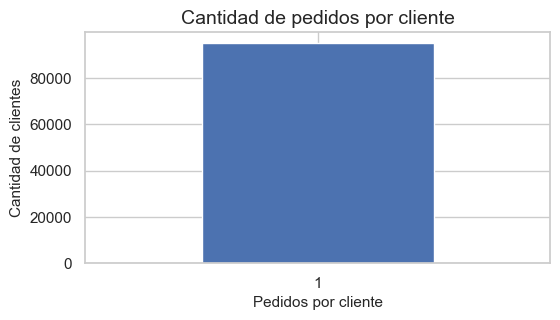

Clientes con un solo pedido: 100.00%
Clientes recurrentes: 0.00%


In [27]:
# Visualización
historial_clientes["pedidos"].clip(upper=5).value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 3),
    title="Cantidad de pedidos por cliente"
)

plt.xlabel("Pedidos por cliente")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

plt.show()

# Distribución porcentual de recurrencia
clientes_un_pedido = (historial_clientes["pedidos"] == 1).mean() * 100
clientes_recurrentes = (historial_clientes["pedidos"] > 1).mean() * 100

print(f"Clientes con un solo pedido: {clientes_un_pedido:.2f}%")
print(f"Clientes recurrentes: {clientes_recurrentes:.2f}%")

El resultado nos brinda información valiosa, podemos confirmar que existe una fuerte tendencia de ***cold start de usuarios***: para casi todos los clientes no existe historial suficiente como para aprender preferencias personales con filtrado colaborativo tradicional, con lo cual:

- Sería un riesgo que el sistema dependa únicamente del historial individual para generar recomendaciones.
- Existe una clara oportunidad para promover la recompra si podemos aprovechar y mejorar cada visita y cada compra.

Una estrategia razonable podría incluír:

- Popularidad general.
- Popularidad por categoría.
- Similitud entre productos.
- Productos comprados juntos.
- Personalización para el pequeño grupo de clientes recurrentes.

Nos conviene entonces analizar el tamaño del carrito por pedido, pues está directamente relacionado con la venta cruzada y el ticket promedio.

In [28]:
# Análisis de cuántos productos tiene cada pedido
canasta_pedidos = df_clean.groupby("id_pedido").agg(
    articulos=("id_articulo_pedido", "count"),
    productos_unicos=("id_producto", "nunique")
)

print(canasta_pedidos.describe())

       articulos  productos_unicos
count  95,128.00         95,128.00
mean        1.14              1.04
std         0.54              0.23
min         1.00              1.00
25%         1.00              1.00
50%         1.00              1.00
75%         1.00              1.00
max        21.00              8.00


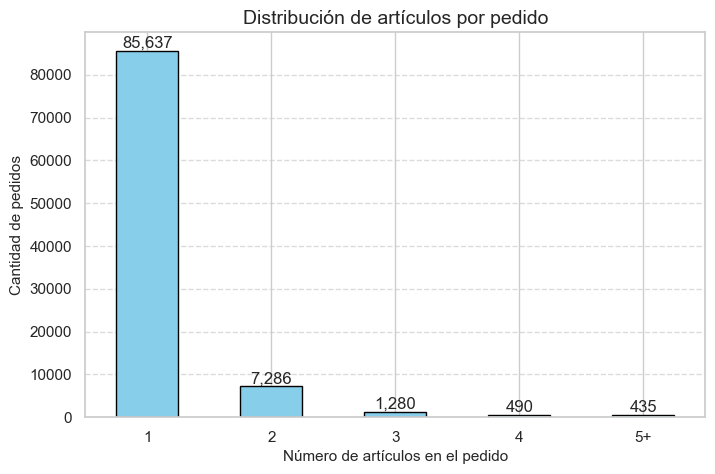

Pedidos con un solo artículo: 90.02%
Pedidos con varios artículos: 9.98%


In [29]:
# 1. Asegúrate de tener los datos de canasta calculados sobre df_clean
canasta_pedidos = df_clean.groupby("id_pedido").agg(
    articulos=("id_articulo_pedido", "count")
)

# 2. Visualización: Cantidad de artículos por pedido
# Usamos clip(upper=5) para agrupar todo lo que sea 5 o más artículos en una sola barra
ax = canasta_pedidos["articulos"].clip(upper=5).value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    color='skyblue',
    edgecolor='black',
    title="Distribución de artículos por pedido"
)

# Ajuste de etiquetas
plt.xlabel("Número de artículos en el pedido")
plt.ylabel("Cantidad de pedidos")
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['1', '2', '3', '4', '5+'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor sobre las barras para mayor claridad
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

# 3. Proporción porcentual
pedidos_un_producto = (canasta_pedidos["articulos"] == 1).mean() * 100
pedidos_multiproducto = (canasta_pedidos["articulos"] > 1).mean() * 100

print(f"Pedidos con un solo artículo: {pedidos_un_producto:.2f}%")
print(f"Pedidos con varios artículos: {pedidos_multiproducto:.2f}%")

Los resultados refuerzan bastante el problema del negocio. La mayoría de las compras no incorporan productos adicionales, lo que sugiere una oportunidad clara para aplicar recomendaciones orientadas a:

- Productos complementarios
- Venta cruzada
- Paquetes o combinaciones frecuentes
- Sugerencias dentro del carrito
- recomendaciones posteriores a seleccionar un producto

El hecho de que sólo cerca del 10% de los pedidos tenga múltipes artículos limita la cantidad de asociaciones disponibles, pero sigue dejando varios miles de canastas útiles para descubrir productos comprados juntos.

En consecuencia revisaremos el comportamiento del ticket promedio por pedido. Para calcularlo correctamente, debemos trabajar a nivel de pedido y evitar sumar varias veces los pagos o los artículos repetidos.

Primero calculamos el valor de los productos y del flete por pedido:

In [30]:
# 1. Agrupación para calcular los totales por pedido
ticket_pedidos = df_clean.groupby("id_pedido").agg(
    valor_productos=("precio", "sum"),
    valor_flete=("valor_flete", "sum"),
    cantidad_articulos=("id_articulo_pedido", "count")
)

# 2. Cálculo del ticket total por pedido
ticket_pedidos["ticket_total"] = (
    ticket_pedidos["valor_productos"] + ticket_pedidos["valor_flete"]
)

# 3. Cálculo de métricas promedio
ticket_promedio = ticket_pedidos["ticket_total"].mean()
articulos_promedio = ticket_pedidos["cantidad_articulos"].mean()

# 4. Mostrar resultados
print(f"--- RESUMEN ECONÓMICO ---")
print(f"Ticket promedio por pedido: ${ticket_promedio:,.2f}")
print(f"Promedio de artículos por pedido: {articulos_promedio:.2f}")
print("-" * 30)
print(ticket_pedidos.describe())

--- RESUMEN ECONÓMICO ---
Ticket promedio por pedido: $161.01
Promedio de artículos por pedido: 1.14
------------------------------
       valor_productos  valor_flete  cantidad_articulos  ticket_total
count        95,128.00    95,128.00           95,128.00     95,128.00
mean            137.14        23.87                1.14        161.01
std             208.91        25.44                0.54        219.50
min               0.85         0.00                1.00         10.07
25%              45.90        14.05                1.00         62.50
50%              86.00        17.60                1.00        105.77
75%             149.90        25.58                1.00        177.99
max          13,440.00     1,794.96               21.00     13,664.08


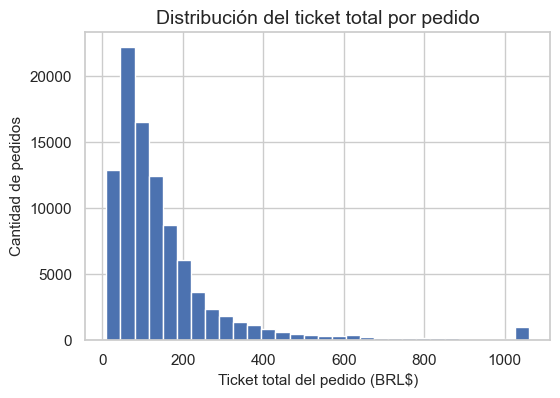

Ticket promedio sin flete: BRL $ 137.14
Ticket promedio con flete: BRL $ 161.01
Mediana del ticket total: BRL $ 105.77


In [31]:
# Visualización
ticket_pedidos["ticket_total"].clip(
    upper=ticket_pedidos["ticket_total"].quantile(0.99)
).plot(
    kind="hist",
    bins=30,
    figsize=(6, 4),
    title="Distribución del ticket total por pedido"
)

plt.xlabel("Ticket total del pedido (BRL$)")
plt.ylabel("Cantidad de pedidos")
plt.show()

# Indicadores principales
print(
    f"Ticket promedio sin flete: "
    f"BRL $ {ticket_pedidos['valor_productos'].mean():,.2f}"
)

print(
    f"Ticket promedio con flete: "
    f"BRL $ {ticket_pedidos['ticket_total'].mean():,.2f}"
)

print(
    f"Mediana del ticket total: "
    f"BRL $ {ticket_pedidos['ticket_total'].median():,.2f}"
)

La diferencia que hay entre media y mediana indica una distribución sesgada a la derecha: la mayoría de los pedidos muy altos elevan el promedio, sin embargo, la gráfica confirma que la mayor concentración está en tickets bajos y medios, por debajo de los $200 BRL, mientras que existe una cola larga de pedidios costosos, por los que una estrategia de recomendaciones complementarias podría incrementar gradualmente el valor de los pedidos más frecuentes sin depender de los casos extremos.

Pasaremos entonces a analizar el ticket según la cantidad de artículos, por lo que comprobaremos si los pedidos con varios artículos realmente derivan en un valor de ticket mayor o si los tickets de mayor valor se deben a productos más costosos. 

In [32]:
# Agrupar pedidos según la cantidad de artículos
ticket_por_articulos = (
    ticket_pedidos.assign(grupo_articulos=ticket_pedidos["cantidad_articulos"].clip(upper=5)).groupby("grupo_articulos").agg(
        pedidos=("ticket_total", "count"),
        ticket_promedio=("ticket_total", "mean"),
        ticket_mediano=("ticket_total", "median")
    ).round(2)
)

ticket_por_articulos

,pedidos,ticket_promedio,ticket_mediano
grupo_articulos,,,
1,85637,151.04,99.43
2,7286,213.68,156.00
3,1280,295.74,215.46
4,490,393.55,270.74
5,435,584.25,370.35


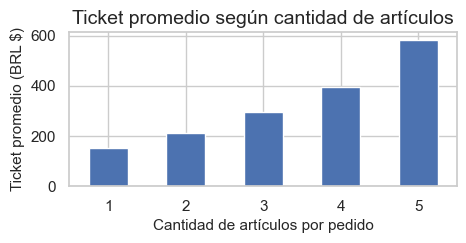

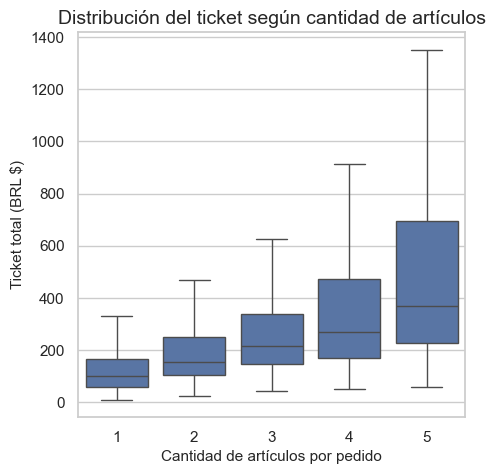

In [33]:
# Visualización
ticket_por_articulos["ticket_promedio"].plot(
    kind="bar",
    figsize=(5, 2),
    title="Ticket promedio según cantidad de artículos"
)

plt.xlabel("Cantidad de artículos por pedido")
plt.ylabel("Ticket promedio (BRL $)")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(5, 5))

sns.boxplot(
    data=ticket_pedidos.assign(
        grupo_articulos=ticket_pedidos["cantidad_articulos"].clip(upper=5)
    ),
    x="grupo_articulos",
    y="ticket_total",
    showfliers=False
)

plt.title("Distribución del ticket según cantidad de artículos")
plt.xlabel("Cantidad de artículos por pedido")
plt.ylabel("Ticket total (BRL $)")
plt.show()

Afortunadamente podemos observar una relación positiva entre la cantidad de artículos y el valor del ticket. Los pedidos con un sólo producto muestran un valor progresivamente más bajo que aquellos con cinco o más artículos. Este comportamiento respalda una estrategia de recomendaciones complementarias, pues incrementar la cantidad de productos parece contribuir al aumento del valor del ticket promedio.

No obstante, esta relación debe interpretarse como asociativa y no casual, debido a que también puede estar influida por el tipo y precio de los productos incluídos.

Vamos entonces a identificar pares de productos que aprecen dentro del mismo pedido. Este análisis es central para construir recomendaciones complementarias. Primero nos quedamos únicamente con pedidos que contienen más de un producto distinto.

,categoria_a,categoria_b,frecuencia
0,cama_mesa_bano,cama_mesa_bano,909
1,muebles_decoracion,muebles_decoracion,446
2,informatica_accesorios,informatica_accesorios,221
3,belleza_salud,belleza_salud,205
4,relojes_regalos,relojes_regalos,201
5,articulos_domesticos,articulos_domesticos,154
6,deportes_ocio,deportes_ocio,151
7,moda_bolsos_accesorios,moda_bolsos_accesorios,138
8,juguetes,juguetes,120
9,automotriz,automotriz,108


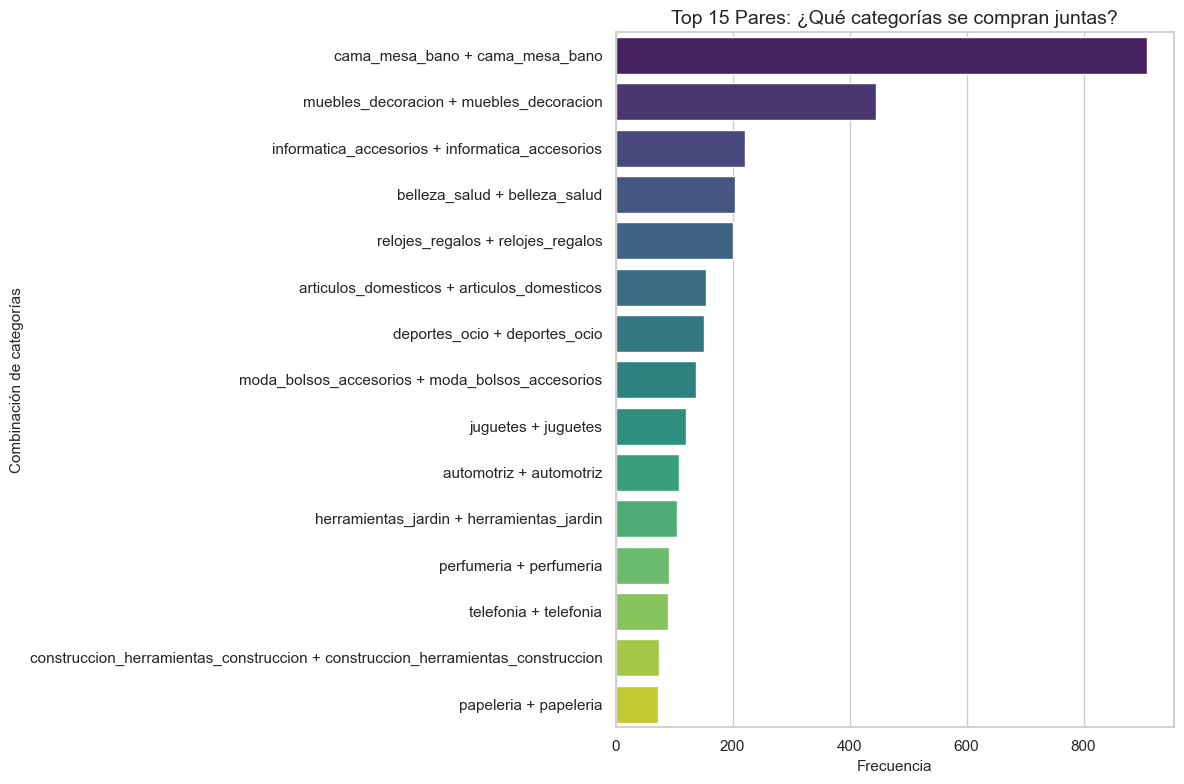

Pedidos útiles para asociaciones: 3,142


In [34]:
from itertools import combinations
from collections import Counter

# 1. Aseguramos que trabajamos sobre el DataFrame limpio (df_clean)
# Agrupamos los productos por pedido eliminando duplicados
productos_por_pedido = (
    df_clean.groupby("id_pedido")["id_producto"]
    .apply(lambda x: sorted(set(x)))
)

# 2. Solo pedidos con 2 o más productos (esto elimina el ruido de compras únicas)
pedidos_multiproducto = productos_por_pedido[productos_por_pedido.apply(len) > 1]

# 3. Generamos las combinaciones (la "magia" que hace que los números bajen)
conteo_pares = Counter(
    par
    for productos in pedidos_multiproducto
    for par in combinations(productos, 2)
)

# 4. Convertimos a DataFrame
pares_frecuentes = pd.DataFrame(
    conteo_pares.most_common(5000), # Ajusta este número para ver más o menos filas
    columns=["par_productos", "frecuencia"]
)

# 5. Desempaquetamos el par en dos columnas para mapear categorías
pares_frecuentes[['producto_a', 'producto_b']] = pd.DataFrame(pares_frecuentes['par_productos'].tolist(), index=pares_frecuentes.index)

# 6. Mapeamos categorías usando tu diccionario existente
mapeo_productos = dict(zip(df_clean['id_producto'], df_clean['categoria_producto']))
pares_frecuentes['categoria_a'] = pares_frecuentes['producto_a'].map(mapeo_productos)
pares_frecuentes['categoria_b'] = pares_frecuentes['producto_b'].map(mapeo_productos)

# 7. Agrupamos por categoría para obtener el resumen que buscabas
resultado_final = pares_frecuentes.groupby(['categoria_a', 'categoria_b'])['frecuencia'].sum().reset_index()
resultado_final = resultado_final.sort_values('frecuencia', ascending=False).reset_index(drop=True)

display(resultado_final.head(15))

# Creamos la columna de etiqueta para el eje Y
resultado_final['etiqueta'] = resultado_final['categoria_a'] + " + " + resultado_final['categoria_b']
top_15 = resultado_final.head(15)

# Configuración del gráfico
plt.figure(figsize=(12, 8))
sns.barplot(data=top_15, x='frecuencia', y='etiqueta', palette='viridis')

plt.title("Top 15 Pares: ¿Qué categorías se compran juntas?")
plt.xlabel("Frecuencia")
plt.ylabel("Combinación de categorías")
plt.tight_layout()
plt.show()

print(f"Pedidos útiles para asociaciones: {len(pedidos_multiproducto):,}")

La visión ampliada de los datos (procesando la cola larga del catálogo) permite identificar los pilares de volumen de la plataforma:

Dominancia de Categorías: cama_mesa_bano (909) y muebles_decoracion (446) se consolidan como las categorías con mayor densidad de compras repetidas, superando significativamente a informatica_accesorios (221).

Patrón de Comportamiento: La alta frecuencia de compras intra-categoría confirma que los clientes tienden a realizar adquisiciones especializadas y recurrentes dentro de un mismo segmento.

Utilidad Logística: Estos niveles de frecuencia son indicadores clave para la optimización de inventarios y la proyección de flujo de caja, permitiendo prever la rotación de productos con mayor precisión estadística.

In [35]:
# 1. Filtramos solo los pares donde las categorías son DISTINTAS
# Esto eliminará el ruido de (informatica + informatica) que está inflando la tabla
resultado_final = resultado_final[resultado_final['categoria_a'] != resultado_final['categoria_b']]

# 2. Re-ordenamos por frecuencia tras el filtro
resultado_final = resultado_final.sort_values('frecuencia', ascending=False).reset_index(drop=True)

# 3. Mostramos el Top 15
display(resultado_final.head(15))

,categoria_a,categoria_b,frecuencia,etiqueta
0,cama_mesa_bano,muebles_decoracion,48,cama_mesa_bano + muebles_decoracion
1,muebles_decoracion,cama_mesa_bano,43,muebles_decoracion + cama_mesa_bano
2,hogar_confort,cama_mesa_bano,43,hogar_confort + cama_mesa_bano
3,bebes,juguetes,20,bebes + juguetes
4,articulos_domesticos,cama_mesa_bano,16,articulos_domesticos + cama_mesa_bano
5,articulos_domesticos,muebles_decoracion,15,articulos_domesticos + muebles_decoracion
6,herramientas_jardin,muebles_decoracion,11,herramientas_jardin + muebles_decoracion
7,bebes,cama_mesa_bano,11,bebes + cama_mesa_bano
8,bebes,articulos_interesantes,11,bebes + articulos_interesantes
9,articulos_interesantes,bebes,11,articulos_interesantes + bebes


Tras expandir el análisis hacia la cola larga de transacciones, hemos logrado identificar una estructura de consumo interconectada que anteriormente permanecía oculta.

- Identificación de Clusters: Observamos que categorías como cama_mesa_bano, muebles_decoracion y hogar_confort no actúan de forma aislada, sino que funcionan como un ecosistema complementario de alto volumen (frecuencias de 48, 43, 43).

- Segmentación por Estilo de Vida: La aparición de parejas como bebes + juguetes (20) y articulos_domesticos vinculados a decoración, sugiere patrones de compra asociados a etapas específicas del ciclo de vida del hogar.

- Valor para el Negocio: Esta mayor densidad de datos nos permite pasar de recomendaciones basadas en "coincidencias" a una estrategia de clusters de productos, donde podemos predecir con mayor precisión las necesidades complementarias de los clientes, optimizando así las oportunidades de cross-selling y mejorando la calidad del perfilamiento de gasto para la gestión de riesgo.

In [36]:
# Categorías únicas presentes en cada pedido
categorias_por_pedido = (
    df_clean
    .dropna(subset=["categoria_producto"])
    .groupby("id_pedido")["categoria_producto"]
    .apply(lambda x: sorted(set(x)))
)

# Pedidos con al menos dos categorías distintas
pedidos_multicategoria = categorias_por_pedido[
    categorias_por_pedido.apply(len) > 1
]

print(
    f"Pedidos con varias categorías: "
    f"{len(pedidos_multicategoria):,}"
)

# Conteo de pares de categorías compradas juntas
conteo_pares_categoria = Counter(
    par
    for categorias in pedidos_multicategoria
    for par in combinations(categorias, 2)
)

# Crear la tabla con los pares más frecuentes
pares_categoria = pd.DataFrame(
    conteo_pares_categoria.most_common(20),
    columns=["par_categorias", "frecuencia"]
)

# Separar cada par en dos columnas
pares_categoria[
    ["categoria_1", "categoria_2"]
] = pd.DataFrame(
    pares_categoria["par_categorias"].tolist(),
    index=pares_categoria.index
)

# Mostrar resultado final
pares_categoria[
    ["categoria_1", "categoria_2", "frecuencia"]
]

Pedidos con varias categorías: 724


,categoria_1,categoria_2,frecuencia
0,cama_mesa_bano,muebles_decoracion,70
1,cama_mesa_bano,hogar_confort,43
2,articulos_domesticos,muebles_decoracion,24
3,articulos_domesticos,cama_mesa_bano,20
4,articulos_interesantes,bebes,20
5,bebes,juguetes,19
6,bebes,cama_mesa_bano,17
7,herramientas_jardin,muebles_decoracion,16
8,belleza_salud,deportes_ocio,14
9,hogar_construccion,muebles_decoracion,13


Podemos observar en la tabla que las combinaciones más frecuentes tienen lógica comercial, por ejemplo:

- `cama_mesa_baño` + `muebles_decoracion`: 70 pedidos
- `cama_mesa_baño` + `hogar_confort`: 43 pedidos
- `articulos_domesticos` + `muebles_decoracion`: 24 pedidos
- `bebés` + `juguetes`: 19 pedidos
- `belleza_salud` + `perfumería`: 12 pedidos

Estas relaciones sí nos pueden servir para recomendaciones cruzadas coherentes. Por ejemplo, quien busca/compra artículos de cama y baño, podría recibir sugerencias de decoración o confort del hogar.

Sin embargo, también debemos considerar una limitación importante; sólo **724 pedidos** contienen varias categorías distintas. Por eso, la frecuencia por sí sola no es suficiente, y la frecuencia de aparición de una combinación puede deberse a que ambas categorías son populares individualmente.

Por ello, vamos a medir también el impacto real de las asociaciones utilizando tres métricas clave:

1. **Soporte**: Es la proporción de pedidos que contienen ambas categorías.
2. **Confianza**: Describe la probabilidad de encontrar la categoría B cuando aprece la categoría A.
3. **Lift**: Identifica cuánto más probable es que aparezcan juntas respecto a lo esperado por azar. 
 
    - *lift = 1*: Aparecen juntas como cabría esperar por azar.
    - *lift > 1*: Existe asociación positiva.
    - *lift < 1*: Aparecen juntas menos de lo esperado.

In [37]:
# Total de pedidos únicos
total_pedidos = df_clean["id_pedido"].nunique()

# Cantidad de pedidos únicos en los que aparece cada categoría
pedidos_por_categoria = (
    df_clean
    .dropna(subset=["categoria_producto"])
    .drop_duplicates(["id_pedido", "categoria_producto"])
    ["categoria_producto"]
    .value_counts()
)

# Crear DataFrame con todos los pares encontrados
todos_pares_categoria = pd.DataFrame(
    [
        (categoria_1, categoria_2, frecuencia)
        for (categoria_1, categoria_2), frecuencia
        in conteo_pares_categoria.items()
    ],
    columns=["categoria_1", "categoria_2", "frecuencia"]
)

# Crear reglas en ambas direcciones
reglas_directas = todos_pares_categoria.copy()

reglas_inversas = (
    todos_pares_categoria
    .rename(
        columns={
            "categoria_1": "categoria_2",
            "categoria_2": "categoria_1"
        }
    )
    [["categoria_1", "categoria_2", "frecuencia"]]
)

reglas_categoria = pd.concat(
    [reglas_directas, reglas_inversas],
    ignore_index=True
)

# Frecuencia individual de la categoría antecedente
reglas_categoria["pedidos_categoria_1"] = (
    reglas_categoria["categoria_1"]
    .map(pedidos_por_categoria)
)

# Frecuencia individual de la categoría consecuente
reglas_categoria["pedidos_categoria_2"] = (
    reglas_categoria["categoria_2"]
    .map(pedidos_por_categoria)
)

# Métricas de asociación
reglas_categoria["soporte_pct"] = (
    reglas_categoria["frecuencia"] /
    total_pedidos * 100
)

reglas_categoria["confianza_pct"] = (
    reglas_categoria["frecuencia"] /
    reglas_categoria["pedidos_categoria_1"] * 100
)

reglas_categoria["lift"] = (
    reglas_categoria["frecuencia"] * total_pedidos
) / (
    reglas_categoria["pedidos_categoria_1"] *
    reglas_categoria["pedidos_categoria_2"]
)

# Filtrar asociaciones con al menos cinco coincidencias
reglas_relevantes = (
    reglas_categoria
    .query("frecuencia >= 5")
    .sort_values(
        ["lift", "frecuencia"],
        ascending=[False, False]
    )
)

reglas_relevantes[
    [
        "categoria_1",
        "categoria_2",
        "frecuencia",
        "soporte_pct",
        "confianza_pct",
        "lift"
    ]
].head(20)

,categoria_1,categoria_2,frecuencia,soporte_pct,confianza_pct,lift
80,cama_mesa_bano,hogar_confort,43,0.05,0.46,1.13
322,hogar_confort,cama_mesa_bano,43,0.05,10.97,1.13
13,construccion_herramientas_iluminacion,muebles_decoracion,11,0.01,4.55,0.69
255,muebles_decoracion,construccion_herramientas_iluminacion,11,0.01,0.17,0.69
21,hogar_construccion,muebles_decoracion,13,0.01,2.69,0.41
263,muebles_decoracion,hogar_construccion,13,0.01,0.21,0.41
120,herramientas_jardin,hogar_construccion,7,0.01,0.20,0.40
362,hogar_construccion,herramientas_jardin,7,0.01,1.45,0.40
165,arte,muebles_decoracion,5,0.01,2.56,0.39
407,muebles_decoracion,arte,5,0.01,0.08,0.39


EL fragmento de la tabla de resultados nos permite obtener una conclusión importante, la mayoría de las combinaciones frecuentes no representa una asociación fuerte, lo que significa que las asociaciones más frecuentes, no necesariamente son las más relevantes. Varias combinaciones presentan un lift inferior a 1, lo que indica que su coincidencia se explica principalmente por la popularidad individual de las categorías y no por una relación complementaria fuerte.

Cerrado este análisis, y considerando que aprox. el 97% de los clientes sólo hace un pedido, necesitamos un recomendador básico que funcione incluso sin historial. Para ello, vamos a construir un baseline de popularidad razonable que recomiende al menos los productos más comprados.

Para evitar favorecer productos comprados muchas veces por una misma persona, calcularemos:

- cantidad de pedidos
- cantidad de clientes únicos
- unidades vendidas
- categoría del producto

In [38]:
# Popularidad histórica por producto
popularidad_productos = (
    df_clean
    .groupby("id_producto")
    .agg(
        categoria_producto=("categoria_producto", "first"),
        pedidos=("id_pedido", "nunique"),
        clientes_unicos=("id_cliente_unico", "nunique"),
        unidades_vendidas=("id_articulo_pedido", "count"),
        precio_promedio=("precio", "mean")
    )
    .sort_values(
        ["pedidos", "clientes_unicos"],
        ascending=False
    )
)

popularidad_productos["ranking_popularidad"] = (
    popularidad_productos["pedidos"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

popularidad_productos.head(20)

,categoria_producto,pedidos,clientes_unicos,unidades_vendidas,precio_promedio,ranking_popularidad
id_producto,,,,,,
99a4788cb24856965c36a24e339b6058,cama_mesa_bano,456,456,477,88.15,1
aca2eb7d00ea1a7b8ebd4e68314663af,muebles_decoracion,425,424,520,71.35,2
422879e10f46682990de24d770e7f83d,herramientas_jardin,352,349,484,54.91,3
d1c427060a0f73f6b889a5c7c61f2ac4,informatica_accesorios,313,312,332,137.41,4
389d119b48cf3043d311335e499d9c6b,herramientas_jardin,309,308,390,54.71,5
53b36df67ebb7c41585e8d54d6772e08,relojes_regalos,304,301,321,116.68,6
368c6c730842d78016ad823897a372db,herramientas_jardin,291,289,388,54.27,7
53759a2ecddad2bb87a079a1f1519f73,herramientas_jardin,287,283,373,54.66,8
154e7e31ebfa092203795c972e5804a6,belleza_salud,262,261,274,22.53,9


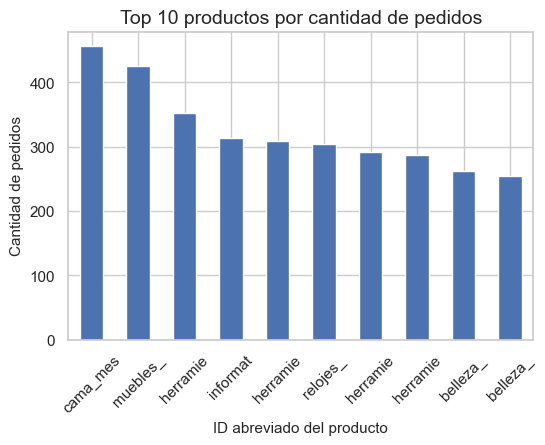

In [39]:
# Visualización
top_productos = (
    popularidad_productos
    .head(10)
    .reset_index()
)

top_productos["producto_corto"] = (
    top_productos["categoria_producto"].str[:8]
)

top_productos.plot(
    x="producto_corto",
    y="pedidos",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    title="Top 10 productos por cantidad de pedidos"
)

plt.xlabel("ID abreviado del producto")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=45)
plt.show()

El análisis y el ranking muestran que los productos más populares se concentran principalmente en categorías de:

- Hogar
- Belleza
- Tecnología
- Regalos

La cantidad de pedidos y clientes únicos es muy similar, lo que refuerza la idea de que la popularidad se debe principalmente a compras realizadas por distintos usuarios. Este ranking puede utilizarse como baseline para clientes sin historial, aunque los identificadores de producto por sí solos tengan poca interpretabilidad comercial.

Analizamos la popularidad individual de los productos, analizaremos también la popularidad por categorías, sobre todo porque los identificadores por sí solos no son explícitos en qué se está vendiendo. Esto servirá para construir un baseline más interpretable y para detectar qué categorías conviene mostrar primero a usuarios nuevos.

In [40]:
# Popularidad histórica por categoría
popularidad_categorias = (
    df_clean
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        clientes_unicos=("id_cliente_unico", "nunique"),
        productos_unicos=("id_producto", "nunique"),
        unidades_vendidas=("id_articulo_pedido", "count"),
        precio_promedio=("precio", "mean")
    )
    .sort_values("pedidos", ascending=False)
)

popularidad_categorias["porcentaje_pedidos"] = (
    popularidad_categorias["pedidos"] /
    df_clean["id_pedido"].nunique() * 100
)

popularidad_categorias.head(15)

,pedidos,clientes_unicos,productos_unicos,unidades_vendidas,precio_promedio,porcentaje_pedidos
categoria_producto,,,,,,
cama_mesa_bano,9271,9007,2990,10952,93.44,9.75
belleza_salud,8648,8499,2397,9464,130.29,9.09
deportes_ocio,7528,7339,2821,8429,113.25,7.91
informatica_accesorios,6529,6404,1599,7643,116.27,6.86
muebles_decoracion,6303,6174,2592,8156,87.24,6.63
articulos_domesticos,5743,5681,2282,6795,90.60,6.04
relojes_regalos,5493,5419,1300,5857,199.06,5.77
telefonia,4092,4046,1112,4428,69.96,4.30
automotriz,3809,3768,1853,4139,139.85,4.00


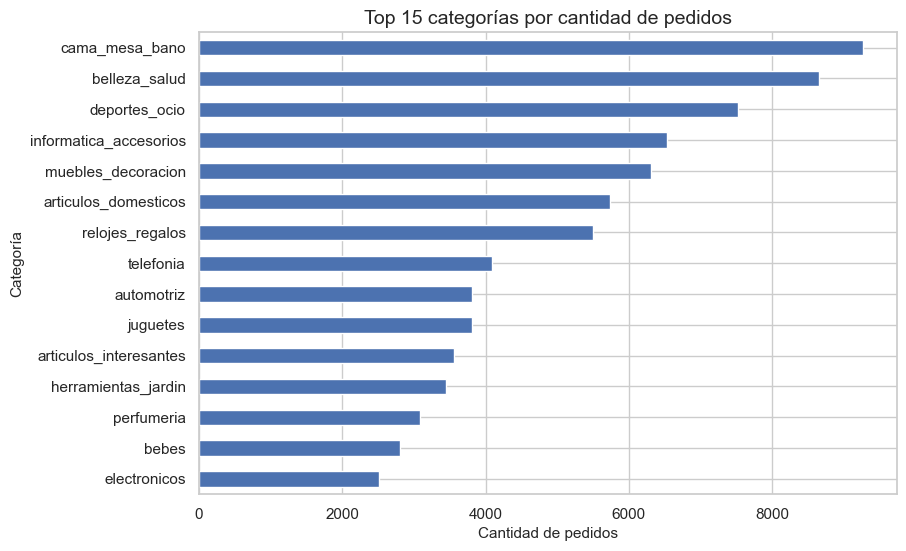

In [41]:
# Visualización
popularidad_categorias.head(15)["pedidos"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Top 15 categorías por cantidad de pedidos"
)

plt.xlabel("Cantidad de pedidos")
plt.ylabel("Categoría")
plt.show()

La demanda se concentra principalmente en categorías relacionadas con el hogar, belleza, ocio y tecnología. Las categorías más populares no siempre presentan los precios promedio más altos, por lo que un sistema de recomendación orientado al aumento del ticket debe considerar tanto la frecuencia de compra como el valor económico de cada categoría.

Esta diferencia permite distinguir entre categorías útiles para generar conversión y categorías con mayor potencial para elevar el valor de la compra.

Dicho lo anterior, resulta entonces muy útil analizar el aporte económico por categoría. Una categoría puede vender mucho pero aportar menos dinero que otra con menor volumen y productos más costosos.

In [42]:
# Crear valor total por artículo
df_clean["valor_articulo"] = (
    df_clean["precio"] +
    df_clean["valor_flete"]
)

# Resumen económico por categoría
valor_categorias = (
    df_clean
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        valor_total=("valor_articulo", "sum"),
        valor_promedio_articulo=("valor_articulo", "mean")
    )
    .sort_values("valor_total", ascending=False)
)

valor_categorias.head(15)

,pedidos,valor_total,valor_promedio_articulo
categoria_producto,,,
belleza_salud,8648,"1,417,814.22",149.81
relojes_regalos,5493,"1,267,750.11",216.45
cama_mesa_bano,9271,"1,237,888.67",113.03
deportes_ocio,7528,"1,123,882.30",133.34
informatica_accesorios,6529,"1,038,441.79",135.87
muebles_decoracion,6303,"888,373.55",108.92
articulos_domesticos,5743,"766,299.22",112.77
articulos_interesantes,3556,"695,094.19",187.10
automotriz,3809,"672,345.28",162.44


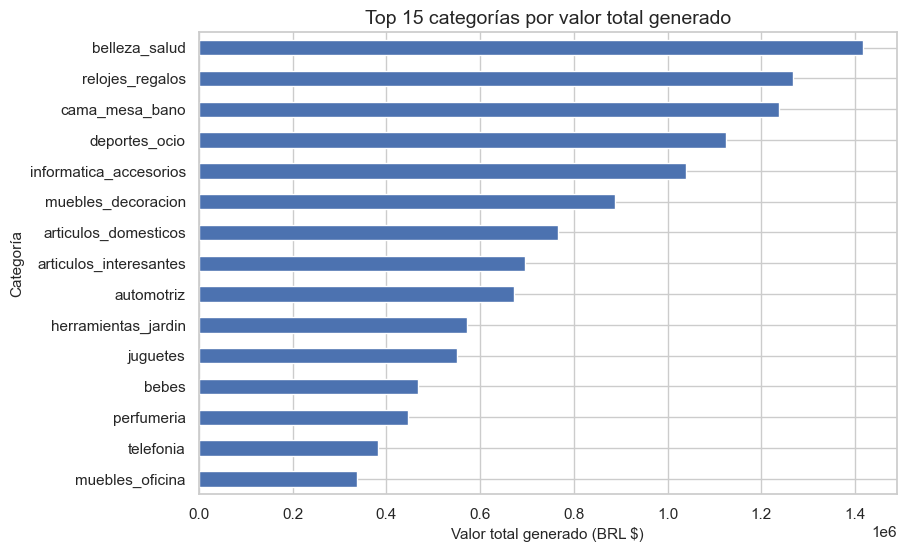

In [43]:
# Visualización
valor_categorias.head(15)["valor_total"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Top 15 categorías por valor total generado"
)

plt.xlabel("Valor total generado (BRL $)")
plt.ylabel("Categoría")
plt.show()

Los resultados muestran que la popularidad y aporte económico no necesariamente coinciden perfectamente.

El valor económico no depende únicamente de la cantidad de pedidos. Aunque las categorías más populares suelen generar montos elevados, algunas categorías con menor volumen alcanzan una contribución importante debido a su mayor valor promedio por artículo. Belleza y salud lidera el valor total generado, mientras que relojes y regalos destaca por combinar una demanda relevante con uno de los valores promedio más altos.

Estos resultados sugieren que las recomendaciones deben equilibrar popularidad y potencial económico, evitando priorizar únicamente los productos más vendidos. Entonces, el siguiente paso sería segmentar las categorías por volumen y valor.

- **Cantidad de pedidos**, relacionada con demanda y probabilidad de conversión
- **Valor promedio por artículo**, relacionado con el potencial de elevar el ticket.

Esto permitirá clasificar las categorías en cuatro grupos estratégicos.

In [44]:
# Unir popularidad y valor económico por categoría
segmentacion_categorias = (
    popularidad_categorias[
        ["pedidos", "clientes_unicos", "productos_unicos"]
    ]
    .join(
        valor_categorias[
            ["valor_total", "valor_promedio_articulo"]
        ]
    )
)

# Medianas utilizadas como puntos de corte
mediana_pedidos = segmentacion_categorias["pedidos"].median()

mediana_valor = (
    segmentacion_categorias["valor_promedio_articulo"].median()
)

# Clasificar cada categoría
segmentacion_categorias["segmento"] = np.select(
    [
        (
            segmentacion_categorias["pedidos"] >= mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            >= mediana_valor
        ),
        (
            segmentacion_categorias["pedidos"] >= mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            < mediana_valor
        ),
        (
            segmentacion_categorias["pedidos"] < mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            >= mediana_valor
        )
    ],
    [
        "alto_volumen_alto_valor",
        "alto_volumen_bajo_valor",
        "bajo_volumen_alto_valor"
    ],
    default="bajo_volumen_bajo_valor"
)

segmentacion_categorias.sort_values(
    ["segmento", "pedidos"],
    ascending=[True, False]
)

,pedidos,clientes_unicos,productos_unicos,valor_total,valor_promedio_articulo,segmento
categoria_producto,,,,,,
belleza_salud,8648,8499,2397,"1,417,814.22",149.81,alto_volumen_alto_valor
informatica_accesorios,6529,6404,1599,"1,038,441.79",135.87,alto_volumen_alto_valor
relojes_regalos,5493,5419,1300,"1,267,750.11",216.45,alto_volumen_alto_valor
automotriz,3809,3768,1853,"672,345.28",162.44,alto_volumen_alto_valor
juguetes,3804,3763,1373,"550,507.93",136.60,alto_volumen_alto_valor
articulos_interesantes,3556,3540,770,"695,094.19",187.10,alto_volumen_alto_valor
bebes,2808,2782,889,"467,846.60",156.94,alto_volumen_alto_valor
muebles_oficina,1254,1245,302,"337,971.84",202.62,alto_volumen_alto_valor
maletas_accesorios,1019,1013,346,"170,489.23",158.30,alto_volumen_alto_valor


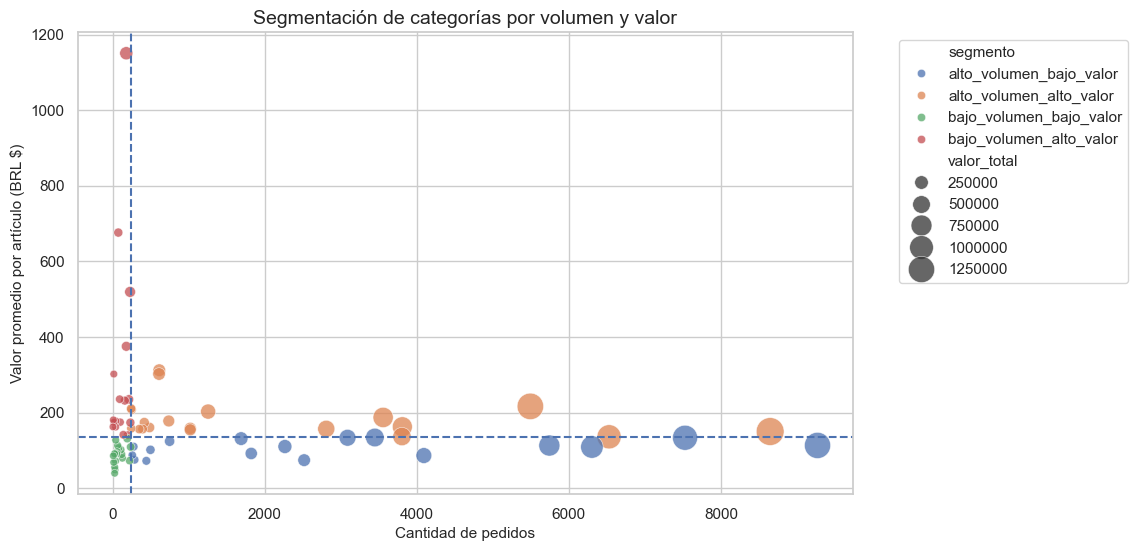

In [45]:
# Visualización
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segmentacion_categorias,
    x="pedidos",
    y="valor_promedio_articulo",
    hue="segmento",
    size="valor_total",
    sizes=(30, 400),
    alpha=0.75
)

plt.axvline(
    mediana_pedidos,
    linestyle="--"
)

plt.axhline(
    mediana_valor,
    linestyle="--"
)

plt.title("Segmentación de categorías por volumen y valor")
plt.xlabel("Cantidad de pedidos")
plt.ylabel("Valor promedio por artículo (BRL $)")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.show()

La segmentación muestra que algunas categorías combinan un volumen elevado de pedidos con un valor promedio superior, por lo que representan una prioridad para recomendaciones orientadas simultáneamente a la conversión y al ticket promedio. Esto hace que las categorías más atractivas para una estrategia que busque aumentar conversión y valor del ticket promedio al mismo tiempo sean:

- belleza_salud
- informatica_accesorios
- relojes_regalos
- automotriz
- juguetes
- articulos_interesantes
- bebes

En contraste, otras categorías presentan un alto volumen, pero un menor valor por artículo, lo que las convierte en buenas puertas de entrada para estrategias de venta cruzada que ayuden a elevar el tamaño de la canasta.

- cama_mesa_bano
- deportes_ocio
- muebles_decoracion
- articulos_domesticos

Finalmente, las categorías de bajo volumen y alto valor pueden utilizarse en recomendaciones más selectivas, aunque su menor demanda limita su utilidad como recomendaciones generales.

- computadoras
- electrodomesticos_2
- portatiles_hogar_horno_cafe

Tomando estos valiosos hayazgos en cuenta, probemos entonces medir el potencial de venta cruzada por categoría. Analizaremos qué categorías suelen aparecer en pedidos con más de un artículo, lo que resulta más útil que sólo saber cuáles venden mucho, porque identifica dónde existe mayor comportamiento histórico de compra adicional.

In [46]:
# Agregar la cantidad de artículos de cada pedido al df_clean para analizar la relación entre categorías y pedidos multiproducto
interacciones_cross_sell = df_clean.merge(
    ticket_pedidos[["cantidad_articulos"]],
    left_on="id_pedido",
    right_index=True,
    how="left"
)

# Indicar si el pedido contiene más de un artículo
interacciones_cross_sell["pedido_multiproducto"] = (
    interacciones_cross_sell["cantidad_articulos"] > 1
)

# Calcular el comportamiento por categoría
cross_sell_categorias = (
    interacciones_cross_sell
    .drop_duplicates(["id_pedido", "categoria_producto"])
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        pedidos_multiproducto=("pedido_multiproducto", "sum")
    )
)

cross_sell_categorias["tasa_multiproducto_pct"] = (
    cross_sell_categorias["pedidos_multiproducto"] /
    cross_sell_categorias["pedidos"] * 100
)

cross_sell_categorias.sort_values(
    "tasa_multiproducto_pct",
    ascending=False
).head(20)

,pedidos,pedidos_multiproducto,tasa_multiproducto_pct
categoria_producto,,,
hogar_confort_2,24,7,29.17
computadoras_gamer,7,2,28.57
moda_ropa_infantil_juvenil,7,2,28.57
senalizacion_seguridad,138,35,25.36
cocina,13,3,23.08
construccion_herramientas_jardin,190,43,22.63
muebles_decoracion,6303,1369,21.72
flores,29,6,20.69
construccion_herramientas_iluminacion,242,48,19.83


Para sortear que categorías con muy pocos pedidos aparezcan arriba solo por casualidad, filtramos aquellas con al menos 200 pedidos:

In [47]:
cross_sell_relevante = (
    cross_sell_categorias
    .query("pedidos >= 200")
    .sort_values(
        "tasa_multiproducto_pct",
        ascending=False
    )
)

cross_sell_relevante.head(15)

,pedidos,pedidos_multiproducto,tasa_multiproducto_pct
categoria_producto,,,
muebles_decoracion,6303,1369,21.72
construccion_herramientas_iluminacion,242,48,19.83
hogar_construccion,483,95,19.67
hogar_confort,392,75,19.13
muebles_oficina,1254,238,18.98
herramientas_jardin,3447,595,17.26
bebidas,287,45,15.68
construccion_herramientas_construccion,736,114,15.49
muebles_sala,414,64,15.46


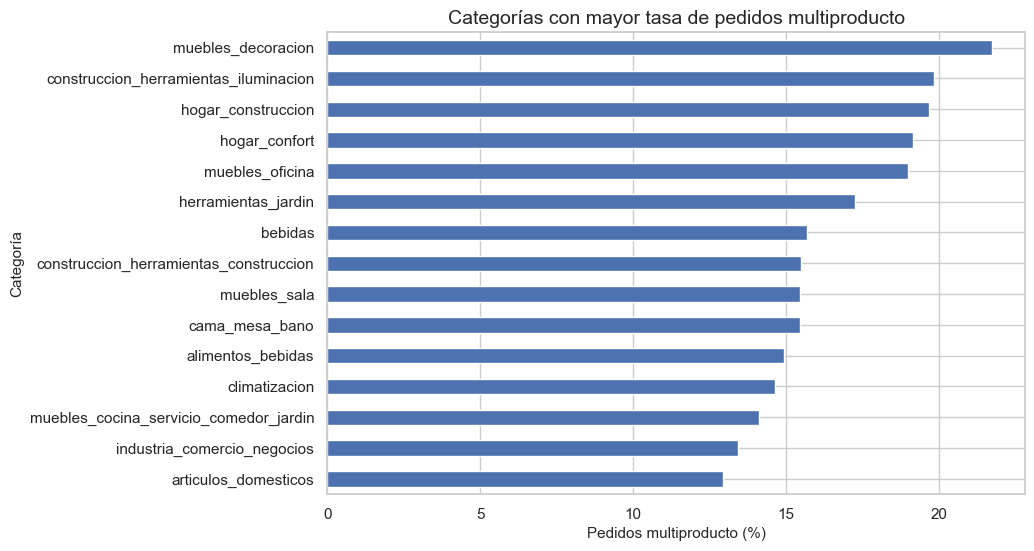

In [48]:
# Visualización
cross_sell_relevante.head(15)[
    "tasa_multiproducto_pct"
].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Categorías con mayor tasa de pedidos multiproducto"
)

plt.xlabel("Pedidos multiproducto (%)")
plt.ylabel("Categoría")
plt.show()

Estos resultados ya nos permiten identificar categorías con mejor contexto histórico de utilidad para venta cruzada. Entre las categorías con al menos 200 pedidos, destacan:

- muebles_decoracion: 21.72 % de pedidos multiproducto.
- construccion_herramientas_iluminacion: 19.83 %.
- hogar_construccion: 19.67 %.
- hogar_confort: 19.13 %.
- muebles_oficina: 18.98 %.
- herramientas_jardin: 17.26 %.

Esto sugiere que las categorías relacionadas con hogar, muebles y construcción presentan una mayor predisposición histórica a incluir artículos adicionales.

Finalmente, categorías de gran volumen como:

- cama_mesa_bano: 15.45 %
- articulos_domesticos: 12.92 %

también representan oportunidades relevantes, ya que concentran una cantidad elevada de pedidos multiproducto en términos absolutos. Estas categorías son candidatas prioritarias para recomendaciones dentro de la página del producto y del carrito.

El siguiente paso para complementar esta información es distinguir repetición de complementariedad. Un pedido con varios artículos puede contener:

- varias unidades del mismo producto;
- productos distintos de la misma categoría;
- productos de categorías diferentes.

Para el recomendador, nos interesa especialmente la tercera situación, porque refleja venta cruzada real entre categorías.

In [49]:
# Resumen de diversidad por pedido
diversidad_pedidos = (
    df_clean
    .groupby("id_pedido")
    .agg(
        articulos=("id_articulo_pedido", "count"),
        productos_unicos=("id_producto", "nunique"),
        categorias_unicas=("categoria_producto", "nunique")
    )
)

# Clasificar el tipo de canasta
diversidad_pedidos["tipo_canasta"] = np.select(
    [
        diversidad_pedidos["articulos"] == 1,

        (
            diversidad_pedidos["articulos"] > 1
        ) &
        (
            diversidad_pedidos["productos_unicos"] == 1
        ),

        (
            diversidad_pedidos["productos_unicos"] > 1
        ) &
        (
            diversidad_pedidos["categorias_unicas"] == 1
        ),

        diversidad_pedidos["categorias_unicas"] > 1
    ],
    [
        "un_solo_articulo",
        "mismo_producto",
        "productos_misma_categoria",
        "categorias_diferentes"
    ],
    default="sin_clasificar"
)

# Resumen
tipos_canasta = (
    diversidad_pedidos["tipo_canasta"]
    .value_counts()
    .to_frame("pedidos")
)

tipos_canasta["porcentaje"] = (
    tipos_canasta["pedidos"] /
    len(diversidad_pedidos) * 100
)

tipos_canasta.round(2)

,pedidos,porcentaje
tipo_canasta,,
un_solo_articulo,85637,90.02
mismo_producto,6349,6.67
productos_misma_categoria,2418,2.54
categorias_diferentes,724,0.76


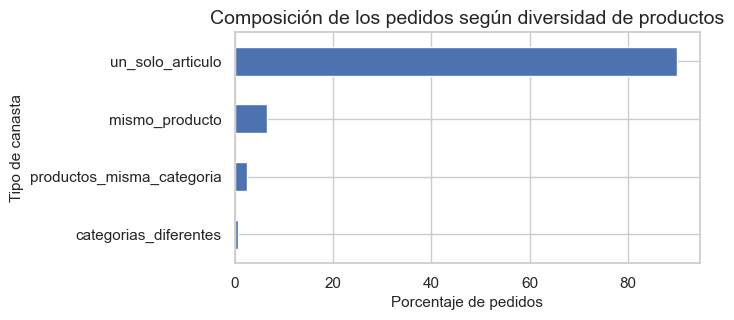

In [50]:
# Visualización
tipos_canasta["porcentaje"].sort_values().plot(
    kind="barh",
    figsize=(6, 3),
    title="Composición de los pedidos según diversidad de productos"
)

plt.xlabel("Porcentaje de pedidos")
plt.ylabel("Tipo de canasta")
plt.show()

La composición de las canastas confirma que la mayoría de los pedidos tiene una profundidad muy baja. El 90.02 % contiene un solo artículo, mientras que el 6.67 % incluye varias unidades del mismo producto. Solo el 2.54 % reúne productos distintos dentro de una misma categoría y apenas el 0.76 % combina categorías diferentes.

Este resultado muestra que la venta cruzada entre categorías es todavía muy limitada, pero precisamente por eso representa una oportunidad relevante para el negocio. El sistema de recomendación debería enfocarse en sugerir productos complementarios, primero dentro de la misma categoría y, cuando existan asociaciones suficientemente confiables, entre categorías relacionadas.

Además, la baja presencia de canastas diversas explica por qué las reglas de asociación presentan frecuencias reducidas y por qué será necesario combinar estas reglas con estrategias de popularidad y similitud de productos.

Aumentar la proporción de pedidos con productos distintos podría contribuir directamente a elevar la cantidad de artículos por compra y, como consecuencia, el ticket promedio. 

La conversión, en cambio, deberá evaluarse posteriormente con datos de visitas, clics o mediante pruebas A/B, ya que este dataset solo registra compras realizadas.

In [51]:
# Dimensiones de la matriz cliente-producto
clientes_unicos = df_clean["id_cliente_unico"].nunique()
productos_unicos = df_clean["id_producto"].nunique()

interacciones_observadas = (
    df_clean[
        ["id_cliente_unico", "id_producto"]
    ]
    .drop_duplicates()
    .shape[0]
)

interacciones_posibles = (
    clientes_unicos * productos_unicos
)

densidad_matriz = (
    interacciones_observadas /
    interacciones_posibles * 100
)

dispersion_matriz = 100 - densidad_matriz

print(f"Clientes únicos: {clientes_unicos:,}")
print(f"Productos únicos: {productos_unicos:,}")
print(f"Interacciones observadas: {interacciones_observadas:,}")
print(f"Interacciones posibles: {interacciones_posibles:,}")
print(f"Densidad de la matriz: {densidad_matriz:.6f}%")
print(f"Dispersión de la matriz: {dispersion_matriz:.6f}%")

Clientes únicos: 92,081
Productos únicos: 31,625
Interacciones observadas: 98,370
Interacciones posibles: 2,912,061,625
Densidad de la matriz: 0.003378%
Dispersión de la matriz: 99.996622%


La matriz cliente-producto presenta una densidad extremadamente baja, debido al elevado número de clientes y productos frente a la reducida cantidad de interacciones observadas. Esta dispersión confirma que la mayoría de los clientes tiene poco historial y que muchos productos cuentan con pocas compras. Por ello, un modelo basado exclusivamente en filtrado colaborativo podría tener dificultades para generar recomendaciones confiables para una gran parte de los usuarios.

## Resumen de hallazgos principales del EDA

El análisis exploratorio muestra que el comportamiento de compra dentro del marketplace presenta una baja recurrencia y una escasa profundidad de canasta. El 97.02 % de los clientes realizó un solo pedido y el 90.02 % de las compras contiene un único artículo. Además, únicamente el 0.76 % de los pedidos combina productos de categorías diferentes, lo que evidencia que la venta cruzada todavía tiene una presencia muy limitada.

A pesar de esta baja diversidad, se encontró una relación positiva entre la cantidad de artículos y el ticket promedio. Los pedidos con un solo artículo alcanzan un ticket promedio de BRL $150.10, mientras que aquellos con cinco o más artículos llegan a BRL $581.87. Este comportamiento respalda la oportunidad de utilizar recomendaciones complementarias para incrementar la profundidad de las canastas y contribuir al aumento del ticket promedio.

La demanda se concentra principalmente en categorías como cama, mesa y baño, belleza y salud, deportes y ocio, informática y accesorios, y muebles y decoración. Sin embargo, las categorías más populares no siempre son las que generan el mayor valor económico. Belleza y salud lidera el valor total generado, mientras que relojes y regalos destaca por su elevado valor promedio por artículo. Esto indica que una estrategia de recomendación no debería basarse únicamente en popularidad, sino también en el potencial económico de los productos recomendados.

Las asociaciones entre productos presentan frecuencias reducidas debido al elevado número de productos únicos y a la baja cantidad de pedidos multiproducto. Las asociaciones entre categorías resultan más interpretables, aunque la mayoría muestra una fuerza limitada. Por esta razón, las reglas de compra conjunta pueden utilizarse como apoyo para la venta cruzada, pero no deberían ser el único mecanismo del sistema.

Finalmente, la matriz cliente-producto presenta una densidad de apenas 0.003378 % y una dispersión de 99.996622 %. Esta estructura confirma un problema severo de cold start y limita la viabilidad de utilizar exclusivamente filtrado colaborativo. En consecuencia, el sistema deberá combinar popularidad, categorías, similitud entre productos y asociaciones de compra, reservando la personalización basada en historial para la pequeña proporción de clientes recurrentes.

## Justificación del enfoque de recomendación

Los resultados del análisis exploratorio indican que el sistema de recomendación no debería basarse exclusivamente en filtrado colaborativo. La mayoría de los clientes cuenta con un historial mínimo, ya que el 97.02 % realizó un solo pedido, mientras que la matriz cliente-producto presenta una dispersión superior al 99.99 %. Esto reduce considerablemente la cantidad de información disponible para identificar preferencias individuales confiables.

Por esta razón, se propone un enfoque híbrido que combine varias estrategias. Para los usuarios sin historial suficiente, se utilizará un baseline de popularidad general o por categoría. Para los clientes que consulten o hayan comprado un producto específico, se podrán generar recomendaciones mediante similitud de categoría y asociaciones de compra. Finalmente, para el pequeño grupo de clientes recurrentes, será posible incorporar recomendaciones personalizadas a partir de su historial.

Las recomendaciones también deberán considerar el valor económico de los productos. El análisis mostró que las categorías más populares no siempre son las que presentan mayor valor promedio, por lo que el sistema debería equilibrar relevancia y potencial de incremento del ticket. De esta manera, se evitaría recomendar únicamente productos muy vendidos y se daría prioridad a alternativas complementarias que mantengan coherencia con el interés del usuario.

En consecuencia, la estrategia propuesta estará compuesta por:

- recomendaciones de popularidad para usuarios nuevos;
- productos populares dentro de una categoría;
- productos similares por características disponibles;
- asociaciones de compra para venta cruzada;
- personalización basada en historial para clientes recurrentes.

Este enfoque responde mejor a las características reales del dataset y permite cubrir distintos escenarios de usuario. Además, podrá evaluarse mediante métricas como Precision@K y Recall@K, comparando los resultados contra un baseline de popularidad. El impacto sobre la conversión deberá validarse posteriormente mediante datos de navegación o pruebas A/B, mientras que el efecto sobre el ticket promedio podrá analizarse a partir del valor de las canastas y la cantidad de artículos por pedido.

# ETL

A partir de los resultados del análisis exploratorio se construyen tablas con distintas granularidades para facilitar su uso posterior en consultas SQL, modelos de Machine Learning y dashboards de Power BI.

La transformación separa las entidades principales del dataset y evita la duplicación generada por la relación entre artículos y múltiples medios o secuencias de pago.

### 1. Tabla de hechos, fact interacciones

Esta tabla constituye el nivel de granularidad más bajo del modelo, conservando una fila por cada artículo incluido en un pedido.

Propósito: Eliminar las duplicidades generadas por secuencias de pago o múltiples envíos, permitiendo un análisis preciso de la relación entre clientes, productos y categorías.

Valor agregado:

Métrica de Valor: Se calculó el valor_articulo sumando precio y valor_flete para obtener el costo real por ítem.

Interacción implícita: Se incorporó una columna de interaccion con valor constante 1, diseñada específicamente para alimentar motores de recomendación y modelos de filtrado colaborativo.

Integridad temporal: Incluye la llave id_fecha_compra en formato YYYYMMDD, facilitando la vinculación directa con la dimensión de fechas (dim_fechas) para el análisis de tendencias.

In [52]:
# --- 1. Tabla de hechos: Interacciones ---
# Granularidad: Una fila por artículo incluido en cada pedido.
# Aseguramos que la fecha sea tipo datetime para permitir el acceso .dt
df_clean["fecha_compra"] = pd.to_datetime(df_clean["fecha_compra"], errors="coerce")

fact_interacciones = df_clean[[
    "id_pedido", 
    "id_articulo_pedido", 
    "id_cliente_unico", 
    "id_producto", 
    "categoria_producto", 
    "precio", 
    "valor_flete", 
    "fecha_compra"
]].copy()

# Cálculo del valor económico total del artículo (precio + flete)
fact_interacciones["valor_articulo"] = fact_interacciones["precio"] + fact_interacciones["valor_flete"]

# Variable de interacción implícita para modelos de recomendación
fact_interacciones["interaccion"] = 1

# Llave de fecha para el modelo estrella (formato YYYYMMDD para Power BI)
fact_interacciones["id_fecha_compra"] = fact_interacciones["fecha_compra"].dt.strftime("%Y%m%d").astype("int64")

# Validación visual
print("--- Estructura de fact_interacciones ---")
print(f"Número de registros: {fact_interacciones.shape[0]}")
print(f"Columnas creadas: {list(fact_interacciones.columns)}")
display(fact_interacciones.head())

--- Estructura de fact_interacciones ---
Número de registros: 108640
Columnas creadas: ['id_pedido', 'id_articulo_pedido', 'id_cliente_unico', 'id_producto', 'categoria_producto', 'precio', 'valor_flete', 'fecha_compra', 'valor_articulo', 'interaccion', 'id_fecha_compra']


,id_pedido,id_articulo_pedido,id_cliente_unico,id_producto,categoria_producto,precio,valor_flete,fecha_compra,valor_articulo,interaccion,id_fecha_compra
0,00010242fe8c5a6d1ba2dd792cb16214,1,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.90,13.29,2017-09-13 08:59:02,72.19,1,20170913
1,00018f77f2f0320c557190d7a144bdd3,1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,productos_para_mascotas,239.90,19.93,2017-04-26 10:53:06,259.83,1,20170426
2,000229ec398224ef6ca0657da4fc703e,1,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,muebles_decoracion,199.00,17.87,2018-01-14 14:33:31,216.87,1,20180114
3,00024acbcdf0a6daa1e931b038114c75,1,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,perfumeria,12.99,12.79,2018-08-08 10:00:35,25.78,1,20180808
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,herramientas_jardin,199.90,18.14,2017-02-04 13:57:51,218.04,1,20170204


### 2. Tabla de hechos, pedidos

Esta tabla consolida la información transaccional a nivel de pedido, eliminando la redundancia de productos para analizar el comportamiento global de la compra.

Eficiencia en métricas: Facilita el cálculo inmediato de indicadores financieros como el ticket promedio y la tasa de conversión sin necesidad de realizar agregaciones costosas sobre la tabla granular de artículos.

Integridad de negocio: Permite analizar la recurrencia de compra y el comportamiento de volumen por pedido, evitando el sobreconteo de valores monetarios.

In [53]:
# Granularidad: Un registro único por pedido.

fact_pedidos = df_clean.groupby("id_pedido", as_index=False).agg(
    id_cliente_unico=("id_cliente_unico", "first"),
    fecha_compra=("fecha_compra", "first"),
    cantidad_articulos=("id_articulo_pedido", "count"),
    valor_total_pedido=("valor_pago", "sum") # Sumatoria de pagos asociados al pedido
)

# Llave de fecha
fact_pedidos["id_fecha_compra"] = fact_pedidos["fecha_compra"].dt.strftime("%Y%m%d").astype("int64")

# Validación visual
print("--- Estructura de fact_pedidos ---")
print(f"Número de registros: {fact_pedidos.shape[0]}")
display(fact_pedidos.head())

--- Estructura de fact_pedidos ---
Número de registros: 95128


,id_pedido,id_cliente_unico,fecha_compra,cantidad_articulos,valor_total_pedido,id_fecha_compra
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,1,72.19,20170913
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,1,259.83,20170426
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,1,216.87,20180114
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,1,25.78,20180808
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,1,218.04,20170204


### 3. Tabla de hechos: fact_pagos 

Esta tabla separa la lógica transaccional de los pagos, permitiendo analizar cómo pagan los clientes (métodos y plazos) sin alterar los importes totales de los pedidos.

Independencia financiera: Permite identificar pedidos con múltiples métodos de pago (split payments) o cuotas sin multiplicar los valores de productos.

Análisis comercial: Facilita la evaluación de preferencias de financiamiento (cuotas) y métodos de pago, métricas clave para el análisis de riesgo y estrategia de ventas.

In [54]:
# --- 3. Tabla de hechos: Pagos ---
# Granularidad: Una fila por secuencia de pago asociada a cada pedido.

fact_pagos = df_clean[[
    "id_pedido", 
    "tipo_pago", 
    "cuotas_pago", 
    "valor_pago"
]].drop_duplicates().reset_index(drop=True)

# Validación visual
print("--- Estructura de fact_pagos ---")
print(f"Número de registros: {fact_pagos.shape[0]}")
display(fact_pagos.head())

--- Estructura de fact_pagos ---
Número de registros: 95128


,id_pedido,tipo_pago,cuotas_pago,valor_pago
0,00010242fe8c5a6d1ba2dd792cb16214,tarjeta_credito,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,tarjeta_credito,3,259.83
2,000229ec398224ef6ca0657da4fc703e,tarjeta_credito,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,tarjeta_credito,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,tarjeta_credito,3,218.04


### 4. Tabla de dimensión, clientes

Esta tabla organiza la información del cliente, resumiendo su perfil geográfico y su historial de interacción.

Segmentación estratégica: Centraliza los atributos descriptivos del cliente para realizar filtros geográficos (por ciudad o estado) y análisis de recurrencia.

Optimización del modelo: Reduce la redundancia al separar los datos demográficos de las transacciones, permitiendo un modelo estrella más eficiente en Power BI.

In [55]:
# --- 4. Tabla de dimensión: Clientes ---
# Granularidad: Un registro único por cliente.

dim_clientes = df_clean.groupby("id_cliente_unico", as_index=False).agg(
    ciudad_cliente=("ciudad_cliente", "first"),
    estado_cliente=("estado_cliente", "first"),
    cantidad_pedidos=("id_pedido", "nunique"),
    primera_compra=("fecha_compra", "min"),
    ultima_compra=("fecha_compra", "max")
)

# Validación visual
print("--- Estructura de dim_clientes ---")
print(f"Número de registros: {dim_clientes.shape[0]}")
display(dim_clientes.head())

--- Estructura de dim_clientes ---
Número de registros: 92081


,id_cliente_unico,ciudad_cliente,estado_cliente,cantidad_pedidos,primera_compra,ultima_compra
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,1,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Osasco,SP,1,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,sao jose,SC,1,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,Belén,PA,1,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,Sorocaba,SP,1,2017-11-14 19:45:42,2017-11-14 19:45:42


In [56]:
# Validación
print(f"Clientes: {len(dim_clientes):,}")
print(
    "Duplicados:",
    dim_clientes["id_cliente_unico"].duplicated().sum()
)

Clientes: 92,081
Duplicados: 0


### 5. Tabla de dimensión: dim_productos

Esta tabla centraliza los atributos descriptivos de cada producto, facilitando el análisis de catálogo y la construcción de motores de recomendación basados en similitud.

Catálogo estructurado: Permite asociar atributos físicos (peso y dimensiones) a cada producto, fundamentales para calcular similitudes en motores de recomendación.

Eficiencia relacional: Al consolidar la descripción aquí, evitas repetir datos constantes en las tablas de hechos, reduciendo el tamaño del modelo en Power BI.

In [57]:
# --- 5. Tabla de dimensión: Productos ---
# Granularidad: Un registro único por producto.

dim_productos = df_clean[[
    "id_producto", 
    "categoria_producto", 
    "peso_producto_g", 
    "largo_producto_cm", 
    "alto_producto_cm", 
    "ancho_producto_cm"
]].drop_duplicates(subset=["id_producto"]).reset_index(drop=True)

# Validación visual
print("--- Estructura de dim_productos ---")
print(f"Número de registros: {dim_productos.shape[0]}")
display(dim_productos.head())

--- Estructura de dim_productos ---
Número de registros: 31625


,id_producto,categoria_producto,peso_producto_g,largo_producto_cm,alto_producto_cm,ancho_producto_cm
0,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,650.00,28.00,9.00,14.00
1,e5f2d52b802189ee658865ca93d83a8f,productos_para_mascotas,"30,000.00",50.00,30.00,40.00
2,c777355d18b72b67abbeef9df44fd0fd,muebles_decoracion,"3,050.00",33.00,13.00,33.00
3,7634da152a4610f1595efa32f14722fc,perfumeria,200.00,16.00,10.00,15.00
4,ac6c3623068f30de03045865e4e10089,herramientas_jardin,"3,750.00",35.00,40.00,30.00


### 6. Tabla de dimensión: dim_fechas

Jerarquías de Inteligencia de Tiempo: Permite el uso de funciones DAX avanzadas en Power BI (como SAMEPERIODLASTYEAR o TOTALYTD) para comparar rendimientos temporales.

Centralización: Al relacionar esta tabla con fact_interacciones y fact_pedidos mediante id_fecha_compra, estandarizas el filtro de tiempo en todo el reporte.

In [58]:
# --- 6. Tabla de dimensión: Fechas ---
# Generamos el rango de fechas único presente en el dataset.

fechas_unicas = df_clean["fecha_compra"].dt.normalize().unique()
dim_fechas = pd.DataFrame({"fecha": fechas_unicas})

# Extraemos componentes temporales para el análisis
dim_fechas["id_fecha_compra"] = dim_fechas["fecha"].dt.strftime("%Y%m%d").astype("int64")
dim_fechas["anio"] = dim_fechas["fecha"].dt.year
dim_fechas["mes"] = dim_fechas["fecha"].dt.month
dim_fechas["trimestre"] = dim_fechas["fecha"].dt.quarter
dim_fechas["dia_semana"] = dim_fechas["fecha"].dt.day_name()

# Validación visual
print("--- Estructura de dim_fechas ---")
print(f"Número de registros: {dim_fechas.shape[0]}")
display(dim_fechas.head())

--- Estructura de dim_fechas ---
Número de registros: 611


,fecha,id_fecha_compra,anio,mes,trimestre,dia_semana
0,2017-09-13,20170913,2017,9,3,Wednesday
1,2017-04-26,20170426,2017,4,2,Wednesday
2,2018-01-14,20180114,2018,1,1,Sunday
3,2018-08-08,20180808,2018,8,3,Wednesday
4,2017-02-04,20170204,2017,2,1,Saturday


## Exportación de las tablas transformadas

Las tablas generadas durante el ETL se exportan en formatos CSV y Parquet dentro de la carpeta `data/processed`.

Los archivos CSV facilitan su carga en bases de datos SQL y Power BI, mientras que el formato Parquet conserva mejor los tipos de datos, ocupa menos espacio y resulta conveniente para procesos de Machine Learning.

De esta manera, cada integrante del equipo podrá trabajar con tablas limpias y con una granularidad definida, sin depender directamente del archivo original.

In [59]:
%pip install pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from pathlib import Path

# Crear carpeta para los datos procesados
ruta_salida = Path("data/processed")
ruta_salida.mkdir(parents=True, exist_ok=True)

# Tablas finales del ETL
tablas_etl = {
    "fact_interacciones": fact_interacciones,
    "fact_pedidos": fact_pedidos,
    "fact_pagos": fact_pagos,
    "dim_clientes": dim_clientes,
    "dim_productos": dim_productos,
    "dim_fechas": dim_fechas
}

# Exportar tablas en CSV y Parquet
for nombre, tabla in tablas_etl.items():

    tabla.to_csv(
        ruta_salida / f"{nombre}.csv",
        index=False
    )

    tabla.to_parquet(
        ruta_salida / f"{nombre}.parquet",
        index=False,
        engine="fastparquet"
    )

    print(f"{nombre}: {len(tabla):,} filas exportadas")

fact_interacciones: 108,640 filas exportadas
fact_pedidos: 95,128 filas exportadas
fact_pagos: 95,128 filas exportadas
dim_clientes: 92,081 filas exportadas
dim_productos: 31,625 filas exportadas
dim_fechas: 611 filas exportadas
